# Проект - Маркетинг

**Описание**
  
Интернет-магазин собирает историю покупателей, проводит рассылки предложений и
планирует будущие продажи. Для оптимизации процессов надо выделить пользователей,
которые готовы совершить покупку в ближайшее время.

**Цель**

Предсказать вероятность покупки в течение 90 дней

**Задачи**
 - Изучить данные
 - Разработать полезные признаки
 - Создать модель для классификации пользователей
 - Улучшить модель и максимизировать метрику roc_auc
 - Выполнить тестирование

## Импорт библиотек

In [234]:
# математика
import pandas as pd
import numpy as np

# графики
import seaborn as sns
import matplotlib.pyplot as plt

# для преобразования списка_как_строка в список
import ast

# для подсчета статистических данных в списках
import statistics

# для подсчёта корреляции между признаками разных типов данных
from phik import phik_matrix
from phik.report import plot_correlation_matrix

# модели градиентного бустинга
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# ансамблевая модель МО
from sklearn.ensemble import RandomForestClassifier

# Пайплайны
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# дополнительные классы для преобразования данных
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

from sklearn.model_selection import GridSearchCV

# разделение дафрейма на тестовые и тренировочные данные
from sklearn.model_selection import train_test_split

## Системные настройки

In [2]:
RANDOM_STATE = 1654
TEST_SIZE    = 0.25

## Функции

In [3]:
DATETIME_COLUMNS = []
ID = 'client_id'

def visualize(dataframe: pd.DataFrame) -> None:
    """
    Принимает на вход датафрейм.
    Выводит графики для статистичесого анализа.
    Не возвращает ничего.
    """
    try:
        for column in dataframe.columns:
            if column in DATETIME_COLUMNS:
                pass
            if column == ID:
                print(f'-----------------------------------------------------------')
                print(f'Анализ уникальных идентификаторов: {column}')
                unique_ids = dataframe[ID].nunique()
                print(f'Уникальных ID: {unique_ids} из {len(dataframe)} записей')
            elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):
                print(f'-----------------------------------------------------------')
                print(f'Распределение категориальной величины: {column}')
                plt.figure(figsize=(12, 6))
                dataframe[column].value_counts(ascending=True).plot.bar()
                plt.title(column)
                plt.show()
            # числовые данные
            elif pd.api.types.is_numeric_dtype(dataframe[column]):
                print(f'-----------------------------------------------------------')
                print(f'Распределение числовой величины: {column}')
                print(dataframe[column].describe())
                plt.figure(figsize=(12, 6))
                dataframe[column].hist(bins=100, alpha=0.5)
                plt.title(column)
                plt.show()

                dataframe.boxplot(column=[column])
                plt.title(column, fontsize=14, pad=20)
                plt.show()
            else:
                print(f'-----------------------------------------------------------')
                print(f'Тип данных в столбце {column} : {dataframe[column].dtype}')
    except Exception as e:
        print(f'Cant proceed column {column}. Error: {e}')

In [4]:
def display_missing(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
        Принимает на вход датафрейм.
        Возвращает датафрейм с информацией о пропусках.
    """
    try:
        temp    = dataframe.copy()
        missing = (
            pd.DataFrame(
                {
                    'Кол-во пропусков': temp.isnull().sum(),
                    'Доля пропусков %': temp.isnull().mean().round(4) * 100
                }
            ).style.background_gradient(cmap='coolwarm')
        )
    except Exception as e:
        print(f'Error: {e}')
    
    return(missing)

In [5]:
df_apparel_purchases     = pd.read_csv('./data/apparel-purchases.csv')
df_apparel_messages      = pd.read_csv('./data/apparel-messages.csv')
df_apparel_target_binary = pd.read_csv('./data/apparel-target_binary.csv')

In [6]:
df_apparel_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   client_id     202208 non-null  int64  
 1   quantity      202208 non-null  int64  
 2   price         202208 non-null  float64
 3   category_ids  202208 non-null  object 
 4   date          202208 non-null  object 
 5   message_id    202208 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 9.3+ MB


In [7]:
df_apparel_purchases.head(5)

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


In [8]:
df_apparel_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   bulk_campaign_id  int64 
 1   client_id         int64 
 2   message_id        object
 3   event             object
 4   channel           object
 5   date              object
 6   created_at        object
dtypes: int64(2), object(5)
memory usage: 680.4+ MB


In [9]:
df_apparel_messages.head(5)

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


In [10]:
df_apparel_target_binary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  49849 non-null  int64
 1   target     49849 non-null  int64
dtypes: int64(2)
memory usage: 779.0 KB


In [11]:
df_apparel_target_binary.head(5)

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


In [12]:
df_apparel_purchases['date'] = pd.to_datetime(df_apparel_purchases['date'], format="%Y-%m-%d")
df_apparel_messages['date']  = pd.to_datetime(df_apparel_messages['date'], format="%Y-%m-%d")

## Пропуски

In [13]:
display_missing(df_apparel_messages)

,Кол-во пропусков,Доля пропусков %
bulk_campaign_id,0,0.000000
client_id,0,0.000000
message_id,0,0.000000
event,0,0.000000
channel,0,0.000000
date,0,0.000000
created_at,0,0.000000


In [14]:
display_missing(df_apparel_purchases)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
quantity,0,0.000000
price,0,0.000000
category_ids,0,0.000000
date,0,0.000000
message_id,0,0.000000


In [15]:
display_missing(df_apparel_target_binary)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000


## Полные дубликаты

In [16]:
df_apparel_messages_dup_sum      = df_apparel_messages.duplicated().sum()
df_apparel_messages_shape_0      = df_apparel_messages.shape[0]
df_apparel_purchases_dup_sum     = df_apparel_purchases.duplicated().sum()
df_apparel_purchases_shape_0     = df_apparel_purchases.shape[0]
df_apparel_target_binary_dup_sum = df_apparel_target_binary.duplicated().sum()
df_apparel_target_binary_shape_0 = df_apparel_target_binary.shape[0]


print(f'df_apparel_messages - кол-во полных дубликатов строк: {df_apparel_messages_dup_sum}')
print(f'df_apparel_messages - всего строк: {df_apparel_messages_shape_0}')
print(f'df_apparel_messages - процент дубликатов: {(df_apparel_messages_dup_sum / df_apparel_messages_shape_0 * 100):.2f}')
print('\n')

print(f'df_apparel_purchases - кол-во полных дубликатов строк: {df_apparel_purchases_dup_sum}')
print(f'df_apparel_purchases - всего строк: {df_apparel_purchases_shape_0}')
print(f'df_apparel_purchases - процент дубликатов: {(df_apparel_purchases_dup_sum / df_apparel_purchases_shape_0 * 100):.2f}')
print('\n')

print(f'df_apparel_target_binary - кол-во полных дубликатов строк: {df_apparel_target_binary_dup_sum}')
print(f'df_apparel_target_binary - всего строк: {df_apparel_target_binary_shape_0}')
print(f'df_apparel_target_binary - процент дубликатов: {(df_apparel_target_binary_dup_sum / df_apparel_target_binary_shape_0 * 100):.2f}')

df_apparel_messages - кол-во полных дубликатов строк: 48610
df_apparel_messages - всего строк: 12739798
df_apparel_messages - процент дубликатов: 0.38


df_apparel_purchases - кол-во полных дубликатов строк: 73020
df_apparel_purchases - всего строк: 202208
df_apparel_purchases - процент дубликатов: 36.11


df_apparel_target_binary - кол-во полных дубликатов строк: 0
df_apparel_target_binary - всего строк: 49849
df_apparel_target_binary - процент дубликатов: 0.00


### Удаляем дубликаты

In [17]:
df_apparel_messages.drop_duplicates(inplace=True)
df_apparel_purchases.drop_duplicates(inplace=True)

## Изучаем данные

In [18]:
print(f'Нижняя дата для df_apparel_purchases: {df_apparel_purchases['date'].min()}')
print(f'Верхняя дата для df_apparel_purchases: {df_apparel_purchases['date'].max()}')
print('\n')
print(f'Нижняя дата для df_apparel_messages: {df_apparel_messages['date'].min()}')
print(f'Верхняя дата для df_apparel_messages: {df_apparel_messages['date'].max()}')

Нижняя дата для df_apparel_purchases: 2022-05-16 00:00:00
Верхняя дата для df_apparel_purchases: 2024-02-16 00:00:00


Нижняя дата для df_apparel_messages: 2022-05-19 00:00:00
Верхняя дата для df_apparel_messages: 2024-02-15 00:00:00


In [19]:
df_apparel_messages['event'].unique()

array(['open', 'click', 'purchase', 'send', 'unsubscribe', 'hbq_spam',
       'hard_bounce', 'subscribe', 'soft_bounce', 'complain', 'close'],
      dtype=object)

**Заметки**
 
 - В `df_apparel_messages` содержится история действий пользователя:
     - `open` - открыл письмо
     - `click` - перешел по ссылке
     - `purchase` - совершил оплату (покупка!)
     - `send` - письмо отправлено
     - `unsubscribe` - клиент отписался от рассылки
     - `hbq_spam` - клиент отметил как спам
     - `hard_bounce` - ошибки отправки (необратимая)
     - `subscribe` - клиент подписался на рассылку
     - `soft_bounce` - ошибка отправки (обратимая)
     - `complain` - жалобы на рассылку (спам)
     - `close` - клиент завершил подписку (?)

In [20]:
print(f"Кол-во уникальных пользователей в df_apparel_target_binary: {df_apparel_target_binary['client_id'].nunique()}")

print(f"Кол-во уникальных пользователей в df_apparel_purchases: {df_apparel_purchases['client_id'].nunique()}")

print(f"Кол-во уникальных пользователей в df_apparel_messages: {df_apparel_messages['client_id'].nunique()}")

Кол-во уникальных пользователей в df_apparel_target_binary: 49849
Кол-во уникальных пользователей в df_apparel_purchases: 49849
Кол-во уникальных пользователей в df_apparel_messages: 53329


**Заметки**

 - В датасетах разное кол-во уникальных пользователей, будем использовать только тех, которые есть в target.

## Категории

## Выводы

Привязываться к датам я не могу по следующим причинам:
 - Достоверно неизвестно за какой конкретно период были сформированы признаки `target`
 - Использование методов временных рядов не входят в рамки данной задачи

Что следует учитывать:
 - Чем дальше от текущей даты поведенческие паттерны пользователя, тем меньшее влияение они будут оказывать на поведение в будущем. То есть данные за текущий год имеют больший вес чем данные за прошлый.

Следовательно:
 - Перевести данные из формата временных характеристик к формату частотных
 - Аггрегацию данных следует производить по срезам:
     - За 2022 год
     - За 2023 год
     - За 2024 год
     - За последние три месяца 2024, представленных в датасете. (но поскольку в датасете представлены только 2 неполных месяца, будем аггрегировать за весь 2024)
 - Датафрейм при этом становится плоским: в одной строке будет содержаться вся необходимая информация об одном уникальном пользователе

Создадим следующие категории

1) События:

В целом события можно разделить на 3 группы:
 - Позитивные (click, purchase)
 - Негативные (unsubscribe, hard_bounce, hbq_spam, complain)
 - Нейтральные (все остальные неинформативные)

Формируем признаки:

 - Общее кол-во отправленных сообщений за 2022 год `event.send.year.2022.count`
 - Общее кол-во отправленных сообщений за 2023 год `event.send.year.2023.count`
 - Общее кол-во отправленных сообщений за 2024 год `event.send.year.2024.count`
 - Общее кол-во позитивных сообщений за 2022 год `event.positive.year.2022.count`
 - Общее кол-во позитивных сообщений за 2023 год `event.positive.year.2023.count`
 - Общее кол-во позитивных сообщений за 2024 год `event.positive.year.2024.count`
 - Общее кол-во негативных сообщений за 2022 год `event.negative.year.2022.count`
 - Общее кол-во негативных сообщений за 2023 год `event.negative.year.2023.count`
 - Общее кол-во негативных сообщений за 2024 год `event.negative.year.2024.count`

2) Категории покупок:
 
 - Все категории в одном списке `category_ids.all`
 - Мода первой категории `category_ids.first.mode`
 - Мода последней категории `category_ids.last.mode`
 - Кол-во уникальных категорий `category_ids.unique.count`

3) Канал доставки сообщения

 - Суммарное кол-во сообщений через email `channel.email.total`
 - Суммарное кол-во сообщений через push `channel.push.total`
 - Кол-во покупок через email `channel.email.purchase.count`
 - Кол-во покупок через push `channel.push.purchase.count`

4) ~~bulk_campaign_id~~

 - ~~Кол-во уникальных кампаний за 2022 год `bulk_campaign_id.year.2022.count`~~
 - ~~Кол-во уникальных кампаний за 2023 год `bulk_campaign_id.year.2023.count`~~
 - ~~Кол-во уникальных кампаний за 2024 год `bulk_campaign_id.year.2024.count`~~

5) quantity

 - медиана кол-во за 2022 год `quantity.year.2022.median`
 - медиана кол-во за 2023 год `quantity.year.2023.median`
 - медиана кол-во за 2024 год `quantity.year.2024.median`
 - суммарное кол-во за 2022 год `quantity.year.2022.total`
 - суммарное кол-во за 2023 год `quantity.year.2023.total`
 - суммарное кол-во за 2024 год `quantity.year.2024.total`

6) Стоимость 

 - Суммарная стоимость покупок за 2022 год `price.year.2022.sum`
 - Суммарная стоимость покупок за 2023 год `price.year.2023.sum`
 - Суммарная стоимость покупок за 2024 год `price.year.2024.sum`
 - Медианная стоимость покупок за 2022 год `price.year.2022.median`
 - Медианная стоимость покупок за 2023 год `price.year.2023.median`
 - Медианная стоимость покупок за 2024 год `price.year.2024.median`

7) Новых признаков получается много, что может негативно сказаться на обучении модели.
   Здесь буду придерживаться следующей стратегии:
    - Использовать относительные величины вместо абсолютных (снижаем кол-во признаков)
    - Исследовать прищнаки на мультиколлинеарность (проверяем схожесть признаков)

## Разработка признаков

In [21]:
df_dev      = df_apparel_target_binary.copy()
df_dev_init = df_dev.copy()

print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")

Размерность изначального датафрейма: (49849, 2)
Кол-во уникальных client_id        : 49849
Размерность текущего датафрейма    : (49849, 2)


In [22]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000


### Добавляем признак - год

In [23]:
df_apparel_purchases['__date.year'] = df_apparel_purchases['date'].dt.year

In [24]:
df_apparel_messages['__date.year'] = df_apparel_messages['date'].dt.year

### Добавляем признаки event'ов [df_apparel_messages]

In [25]:
rows_2022 = (df_apparel_messages['event'] == 'send') & (df_apparel_messages['__date.year'] == 2022)
rows_2023 = (df_apparel_messages['event'] == 'send') & (df_apparel_messages['__date.year'] == 2023)
rows_2024 = (df_apparel_messages['event'] == 'send') & (df_apparel_messages['__date.year'] == 2024)

df_temp_2022 = df_apparel_messages[rows_2022].groupby(['client_id']).agg({
    'event': ['count']
})

df_temp_2023 = df_apparel_messages[rows_2023].groupby(['client_id']).agg({
    'event': ['count']
})

df_temp_2024 = df_apparel_messages[rows_2024].groupby(['client_id']).agg({
    'event': ['count']
})

In [26]:
df_temp_2022.columns = ['event.send.year.2022.count']
df_temp_2023.columns = ['event.send.year.2023.count']
df_temp_2024.columns = ['event.send.year.2024.count']

In [27]:
intersection = df_temp_2022.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2022 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2023.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2023 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2024.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2024 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых событий не было найдено в 2022 году: 26.64
Процент клиентов, для которых событий не было найдено в 2023 году: 21.25
Процент клиентов, для которых событий не было найдено в 2024 году: 25.52


In [28]:
df_dev = df_dev.merge(df_temp_2022.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2023.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2024.reset_index(), on='client_id', how='left')

In [29]:
df_dev.head(5)

,client_id,target,event.send.year.2022.count,event.send.year.2023.count,event.send.year.2024.count
0,1515915625468060902,0,49.0,71.0,6.0
1,1515915625468061003,1,57.0,88.0,9.0
2,1515915625468061099,0,115.0,84.0,16.0
3,1515915625468061100,0,81.0,158.0,28.0
4,1515915625468061170,0,45.0,143.0,55.0


In [30]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 5)
Кол-во уникальных client_id        : 49849


In [31]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,13282,26.640000
event.send.year.2023.count,10593,21.250000
event.send.year.2024.count,12721,25.520000


In [32]:
# заполним данные нулями - это значит событий типа send не было
df_dev[['event.send.year.2022.count',
        'event.send.year.2023.count',
        'event.send.year.2024.count'
]] = df_dev[['event.send.year.2022.count',
        'event.send.year.2023.count',
        'event.send.year.2024.count'
]].fillna(0)

In [33]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000


In [34]:
# считаем позитивные действия 'click' + 'purchase'
rows_2022 = ((df_apparel_messages['event'] == 'click') | (df_apparel_messages['event'] == 'purchase')) & (df_apparel_messages['__date.year'] == 2022)
rows_2023 = ((df_apparel_messages['event'] == 'click') | (df_apparel_messages['event'] == 'purchase')) & (df_apparel_messages['__date.year'] == 2023)
rows_2024 = ((df_apparel_messages['event'] == 'click') | (df_apparel_messages['event'] == 'purchase')) & (df_apparel_messages['__date.year'] == 2024)

df_temp_2022 = df_apparel_messages[rows_2022].groupby(['client_id']).agg({
    'event': ['count']
})

df_temp_2023 = df_apparel_messages[rows_2023].groupby(['client_id']).agg({
    'event': ['count']
})

df_temp_2024 = df_apparel_messages[rows_2024].groupby(['client_id']).agg({
    'event': ['count']
})

In [35]:
df_temp_2022.columns = ['event.positive.year.2022.count']
df_temp_2023.columns = ['event.positive.year.2023.count']
df_temp_2024.columns = ['event.positive.year.2024.count']

In [36]:
intersection = df_temp_2022.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2022 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2023.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2023 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2024.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2024 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых событий не было найдено в 2022 году: 41.00
Процент клиентов, для которых событий не было найдено в 2023 году: 39.63
Процент клиентов, для которых событий не было найдено в 2024 году: 77.03


In [37]:
df_dev = df_dev.merge(df_temp_2022.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2023.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2024.reset_index(), on='client_id', how='left')

In [38]:
df_dev.head(5)

,client_id,target,event.send.year.2022.count,event.send.year.2023.count,event.send.year.2024.count,event.positive.year.2022.count,event.positive.year.2023.count,event.positive.year.2024.count
0,1515915625468060902,0,49.0,71.0,6.0,13.0,NaN,2.0
1,1515915625468061003,1,57.0,88.0,9.0,NaN,6.0,NaN
2,1515915625468061099,0,115.0,84.0,16.0,5.0,3.0,NaN
3,1515915625468061100,0,81.0,158.0,28.0,NaN,NaN,2.0
4,1515915625468061170,0,45.0,143.0,55.0,9.0,10.0,NaN


In [39]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 8)
Кол-во уникальных client_id        : 49849


In [40]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,20437,41.000000
event.positive.year.2023.count,19757,39.630000
event.positive.year.2024.count,38398,77.030000


In [41]:
# заполним данные нулями - это значит событий типа positive не было
df_dev[['event.positive.year.2022.count',
        'event.positive.year.2023.count',
        'event.positive.year.2024.count'
]] = df_dev[['event.positive.year.2022.count',
        'event.positive.year.2023.count',
        'event.positive.year.2024.count'
]].fillna(0)

In [42]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000


In [43]:
# считаем негативные действия 'unsubscribe', 'hard_bounce', 'hbq_spam', 'complain'
rows_2022 = (
    (df_apparel_messages['event'] == 'unsubscribe') |\
    (df_apparel_messages['event'] == 'hard_bounce') |\
    (df_apparel_messages['event'] == 'hbq_spam') |\
    (df_apparel_messages['event'] == 'complain')
) & (df_apparel_messages['__date.year'] == 2022)

rows_2023 = (
    (df_apparel_messages['event'] == 'unsubscribe') |\
    (df_apparel_messages['event'] == 'hard_bounce') |\
    (df_apparel_messages['event'] == 'hbq_spam') |\
    (df_apparel_messages['event'] == 'complain')
) & (df_apparel_messages['__date.year'] == 2023)

rows_2024 = (
    (df_apparel_messages['event'] == 'unsubscribe') |\
    (df_apparel_messages['event'] == 'hard_bounce') |\
    (df_apparel_messages['event'] == 'hbq_spam') |\
    (df_apparel_messages['event'] == 'complain')
) & (df_apparel_messages['__date.year'] == 2024)

df_temp_2022 = df_apparel_messages[rows_2022].groupby(['client_id']).agg({
    'event': ['count']
})

df_temp_2023 = df_apparel_messages[rows_2023].groupby(['client_id']).agg({
    'event': ['count']
})

df_temp_2024 = df_apparel_messages[rows_2024].groupby(['client_id']).agg({
    'event': ['count']
})

In [44]:
df_temp_2022.columns = ['event.negative.year.2022.count']
df_temp_2023.columns = ['event.negative.year.2023.count']
df_temp_2024.columns = ['event.negative.year.2024.count']

In [45]:
intersection = df_temp_2022.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2022 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2023.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2023 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2024.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2024 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых событий не было найдено в 2022 году: 90.46
Процент клиентов, для которых событий не было найдено в 2023 году: 83.87
Процент клиентов, для которых событий не было найдено в 2024 году: 95.37


In [46]:
df_dev = df_dev.merge(df_temp_2022.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2023.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2024.reset_index(), on='client_id', how='left')

In [47]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 11)
Кол-во уникальных client_id        : 49849


In [48]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,45091,90.460000
event.negative.year.2023.count,41808,83.870000


In [49]:
# заполним данные нулями - это значит событий типа neagtive не было
df_dev[['event.negative.year.2022.count',
        'event.negative.year.2023.count',
        'event.negative.year.2024.count'
]] = df_dev[['event.negative.year.2022.count',
        'event.negative.year.2023.count',
        'event.negative.year.2024.count'
]].fillna(0)

In [50]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


### Добавляем признаки channel'ов доставки сообщений [df_apparel_messages]

In [51]:
df_apparel_messages['channel'].unique()

array(['email', 'mobile_push'], dtype=object)

In [52]:
# канал email
rows_2022 = (df_apparel_messages['channel'] == 'email') & (df_apparel_messages['__date.year'] == 2022)
rows_2023 = (df_apparel_messages['channel'] == 'email') & (df_apparel_messages['__date.year'] == 2023)
rows_2024 = (df_apparel_messages['channel'] == 'email') & (df_apparel_messages['__date.year'] == 2024)

df_temp_2022 = df_apparel_messages[rows_2022].groupby(['client_id']).agg({
    'channel': ['count']
})

df_temp_2023 = df_apparel_messages[rows_2023].groupby(['client_id']).agg({
    'channel': ['count']
})

df_temp_2024 = df_apparel_messages[rows_2024].groupby(['client_id']).agg({
    'channel': ['count']
})

In [53]:
df_temp_2022.columns = ['channel.email.year.2022.count']
df_temp_2023.columns = ['channel.email.year.2023.count']
df_temp_2024.columns = ['channel.email.year.2024.count']

In [54]:
intersection = df_temp_2022.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2022 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2023.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2023 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2024.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2024 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых событий не было найдено в 2022 году: 38.70
Процент клиентов, для которых событий не было найдено в 2023 году: 45.38
Процент клиентов, для которых событий не было найдено в 2024 году: 50.17


In [55]:
df_dev = df_dev.merge(df_temp_2022.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2023.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2024.reset_index(), on='client_id', how='left')

In [56]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 14)
Кол-во уникальных client_id        : 49849


In [57]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


In [58]:
# заполним данные нулями - это значит событий через канал email не было
df_dev[['channel.email.year.2022.count',
        'channel.email.year.2023.count',
        'channel.email.year.2024.count'
]] = df_dev[['channel.email.year.2022.count',
        'channel.email.year.2023.count',
        'channel.email.year.2024.count'
]].fillna(0)

In [59]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


In [60]:
# канал mobile_push
rows_2022 = (df_apparel_messages['channel'] == 'mobile_push') & (df_apparel_messages['__date.year'] == 2022)
rows_2023 = (df_apparel_messages['channel'] == 'mobile_push') & (df_apparel_messages['__date.year'] == 2023)
rows_2024 = (df_apparel_messages['channel'] == 'mobile_push') & (df_apparel_messages['__date.year'] == 2024)

df_temp_2022 = df_apparel_messages[rows_2022].groupby(['client_id']).agg({
    'channel': ['count']
})

df_temp_2023 = df_apparel_messages[rows_2023].groupby(['client_id']).agg({
    'channel': ['count']
})

df_temp_2024 = df_apparel_messages[rows_2024].groupby(['client_id']).agg({
    'channel': ['count']
})

In [61]:
df_temp_2022.columns = ['channel.mobile_push.year.2022.count']
df_temp_2023.columns = ['channel.mobile_push.year.2023.count']
df_temp_2024.columns = ['channel.mobile_push.year.2024.count']

In [62]:
intersection = df_temp_2022.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2022 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2023.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2023 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2024.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2024 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых событий не было найдено в 2022 году: 66.96
Процент клиентов, для которых событий не было найдено в 2023 году: 43.70
Процент клиентов, для которых событий не было найдено в 2024 году: 49.71


In [63]:
df_dev = df_dev.merge(df_temp_2022.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2023.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2024.reset_index(), on='client_id', how='left')

In [64]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 17)
Кол-во уникальных client_id        : 49849


In [65]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


In [66]:
# заполним данные нулями - это значит событий через канал mobile_push не было
df_dev[['channel.mobile_push.year.2022.count',
        'channel.mobile_push.year.2023.count',
        'channel.mobile_push.year.2024.count'
]] = df_dev[['channel.mobile_push.year.2022.count',
        'channel.mobile_push.year.2023.count',
        'channel.mobile_push.year.2024.count'
]].fillna(0)

In [67]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


In [68]:
# совершенные покупки через канал email
rows_2022 = (df_apparel_messages['channel'] == 'email') &\
    (df_apparel_messages['event'] == 'purchase') &\
    (df_apparel_messages['__date.year'] == 2022)

rows_2023 = (df_apparel_messages['channel'] == 'email') &\
    (df_apparel_messages['event'] == 'purchase') &\
    (df_apparel_messages['__date.year'] == 2023)

rows_2024 = (df_apparel_messages['channel'] == 'email') &\
    (df_apparel_messages['event'] == 'purchase') &\
    (df_apparel_messages['__date.year'] == 2024)

df_temp_2022 = df_apparel_messages[rows_2022].groupby(['client_id']).agg({
    'channel': ['count']
})

df_temp_2023 = df_apparel_messages[rows_2023].groupby(['client_id']).agg({
    'channel': ['count']
})

df_temp_2024 = df_apparel_messages[rows_2024].groupby(['client_id']).agg({
    'channel': ['count']
})

In [69]:
df_temp_2022.columns = ['channel.email.purchase.year.2022.count']
df_temp_2023.columns = ['channel.email.purchase.year.2023.count']
df_temp_2024.columns = ['channel.email.purchase.year.2024.count']

In [70]:
intersection = df_temp_2022.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2022 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2023.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2023 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2024.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2024 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых событий не было найдено в 2022 году: 67.44
Процент клиентов, для которых событий не было найдено в 2023 году: 79.76
Процент клиентов, для которых событий не было найдено в 2024 году: 99.36


In [71]:
df_dev = df_dev.merge(df_temp_2022.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2023.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2024.reset_index(), on='client_id', how='left')

In [72]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 20)
Кол-во уникальных client_id        : 49849


In [73]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


In [74]:
# заполним данные нулями - это значит покупок через канал email не было
df_dev[['channel.email.purchase.year.2022.count',
        'channel.email.purchase.year.2023.count',
        'channel.email.purchase.year.2024.count'
]] = df_dev[['channel.email.purchase.year.2022.count',
        'channel.email.purchase.year.2023.count',
        'channel.email.purchase.year.2024.count'
]].fillna(0)

In [75]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


In [76]:
# совершенные покупки через канал mobile_push
rows_2022 = (df_apparel_messages['channel'] == 'mobile_push') &\
    (df_apparel_messages['event'] == 'purchase') &\
    (df_apparel_messages['__date.year'] == 2022)

rows_2023 = (df_apparel_messages['channel'] == 'mobile_push') &\
    (df_apparel_messages['event'] == 'purchase') &\
    (df_apparel_messages['__date.year'] == 2023)

rows_2024 = (df_apparel_messages['channel'] == 'mobile_push') &\
    (df_apparel_messages['event'] == 'purchase') &\
    (df_apparel_messages['__date.year'] == 2024)

df_temp_2022 = df_apparel_messages[rows_2022].groupby(['client_id']).agg({
    'channel': ['count']
})

df_temp_2023 = df_apparel_messages[rows_2023].groupby(['client_id']).agg({
    'channel': ['count']
})

df_temp_2024 = df_apparel_messages[rows_2024].groupby(['client_id']).agg({
    'channel': ['count']
})

In [77]:
df_temp_2022.columns = ['channel.mobile_push.purchase.year.2022.count']
df_temp_2023.columns = ['channel.mobile_push.purchase.year.2023.count']
df_temp_2024.columns = ['channel.mobile_push.purchase.year.2024.count']

In [78]:
intersection = df_temp_2022.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2022 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2023.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2023 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2024.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2024 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых событий не было найдено в 2022 году: 91.01
Процент клиентов, для которых событий не было найдено в 2023 году: 85.94
Процент клиентов, для которых событий не было найдено в 2024 году: 96.61


In [79]:
df_dev = df_dev.merge(df_temp_2022.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2023.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2024.reset_index(), on='client_id', how='left')

In [80]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 23)
Кол-во уникальных client_id        : 49849


In [81]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


In [82]:
# заполним данные нулями - это значит покупок через канал mobile_push не было
df_dev[['channel.mobile_push.purchase.year.2022.count',
        'channel.mobile_push.purchase.year.2023.count',
        'channel.mobile_push.purchase.year.2024.count'
]] = df_dev[['channel.mobile_push.purchase.year.2022.count',
        'channel.mobile_push.purchase.year.2023.count',
        'channel.mobile_push.purchase.year.2024.count'
]].fillna(0)

In [83]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


### Добавляем признаки quantity - [df_apparel_purchases]

In [84]:
df_apparel_purchases.head()

,client_id,quantity,price,category_ids,date,message_id,__date.year
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d,2022
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d,2022
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843,2022
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843,2022
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843,2022


In [85]:
# суммарное и медианное кол-во покупок
rows_2022 = df_apparel_purchases['__date.year'] == 2022
rows_2023 = df_apparel_purchases['__date.year'] == 2023
rows_2024 = df_apparel_purchases['__date.year'] == 2024

df_temp_2022 = df_apparel_purchases[rows_2022].groupby(['client_id']).agg({
    'quantity': ['sum', 'median']
})

df_temp_2023 = df_apparel_purchases[rows_2023].groupby(['client_id']).agg({
    'quantity': ['sum', 'median']
})

df_temp_2024 = df_apparel_purchases[rows_2024].groupby(['client_id']).agg({
    'quantity': ['sum', 'median']
})

In [86]:
df_temp_2022.columns = ['quantity.year.2022.sum', 'quantity.year.2022.median']
df_temp_2023.columns = ['quantity.year.2023.sum', 'quantity.year.2023.median']
df_temp_2024.columns = ['quantity.year.2024.sum', 'quantity.year.2024.median']

In [87]:
intersection = df_temp_2022.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2022 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2023.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2023 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2024.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2024 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых событий не было найдено в 2022 году: 48.93
Процент клиентов, для которых событий не было найдено в 2023 году: 50.73
Процент клиентов, для которых событий не было найдено в 2024 году: 94.95


In [88]:
df_dev = df_dev.merge(df_temp_2022.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2023.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2024.reset_index(), on='client_id', how='left')

In [89]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 29)
Кол-во уникальных client_id        : 49849


In [90]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


In [91]:
# заполним данные нулями - это значит покупок не было
df_dev[['quantity.year.2022.sum',
        'quantity.year.2023.sum',
        'quantity.year.2024.sum',
        'quantity.year.2022.median',
        'quantity.year.2023.median',
        'quantity.year.2024.median'
]] = df_dev[['quantity.year.2022.sum',
        'quantity.year.2023.sum',
        'quantity.year.2024.sum',
        'quantity.year.2022.median',
        'quantity.year.2023.median',
        'quantity.year.2024.median'
]].fillna(0)

In [92]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


### Добавляем признаки price - [df_apparel_purchases]

In [93]:
# суммарное и медианное кол-во покупок
rows_2022 = df_apparel_purchases['__date.year'] == 2022
rows_2023 = df_apparel_purchases['__date.year'] == 2023
rows_2024 = df_apparel_purchases['__date.year'] == 2024

df_temp_2022 = df_apparel_purchases[rows_2022].groupby(['client_id']).agg({
    'price': ['sum', 'median']
})

df_temp_2023 = df_apparel_purchases[rows_2023].groupby(['client_id']).agg({
    'price': ['sum', 'median']
})

df_temp_2024 = df_apparel_purchases[rows_2024].groupby(['client_id']).agg({
    'price': ['sum', 'median']
})

In [94]:
df_temp_2022.columns = ['price.year.2022.sum', 'price.year.2022.median']
df_temp_2023.columns = ['price.year.2023.sum', 'price.year.2023.median']
df_temp_2024.columns = ['price.year.2024.sum', 'price.year.2024.median']

In [95]:
intersection = df_temp_2022.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2022 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2023.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2023 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

intersection = df_temp_2024.reset_index()['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых событий не было найдено в 2024 году: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых событий не было найдено в 2022 году: 48.93
Процент клиентов, для которых событий не было найдено в 2023 году: 50.73
Процент клиентов, для которых событий не было найдено в 2024 году: 94.95


In [96]:
df_dev = df_dev.merge(df_temp_2022.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2023.reset_index(), on='client_id', how='left')
df_dev = df_dev.merge(df_temp_2024.reset_index(), on='client_id', how='left')

In [97]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 35)
Кол-во уникальных client_id        : 49849


In [98]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


In [99]:
# заполним данные нулями - это значит покупок не было
df_dev[['price.year.2022.sum',
        'price.year.2023.sum',
        'price.year.2024.sum',
        'price.year.2022.median',
        'price.year.2023.median',
        'price.year.2024.median'
]] = df_dev[['price.year.2022.sum',
        'price.year.2023.sum',
        'price.year.2024.sum',
        'price.year.2022.median',
        'price.year.2023.median',
        'price.year.2024.median'
]].fillna(0)

In [100]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


### Добавляем признаки category_ids - [df_apparel_purchases]

In [101]:
# в списках могут быть None объекты
rows = df_apparel_purchases['category_ids'] == '[None]'

df_apparel_purchases[rows]

,client_id,quantity,price,category_ids,date,message_id,__date.year
14848,1515915625649908756,1,2499.0,[None],2022-06-17,1515915625649908756-4981-62ac2dbf52fad,2022
32281,1515915625578652401,1,8.0,[None],2022-08-19,1515915625815834300-5922-62ff35494e05f,2022
32283,1515915625578652401,1,1.0,[None],2022-08-19,1515915625815834300-5922-62ff35494e05f,2022
33447,1515915625468141353,1,7.0,[None],2022-08-25,1515915625468141353-5922-62ff3544b2556,2022
33982,1515915625468112307,1,3.0,[None],2022-08-29,1515915625468112307-6223-630c9088d251c,2022
...,...,...,...,...,...,...,...
61454,1515915625809501946,1,7.0,[None],2022-11-26,1515915625809501946-8120-638061080f2a3,2022
61509,1515915625863557954,1,6.0,[None],2022-11-26,1515915625863557954-8169-6381ebca6e56b,2022
61643,1515915625498389673,1,7.0,[None],2022-11-27,1515915625498389673-8033-637dbe2f79e78,2022
61835,1515915625642965095,1,7.0,[None],2022-11-27,1515915625642965095-8169-6381ebba96708,2022


In [102]:
# заменим на пустой список для упрощения дальнейших статистических исследований
df_apparel_purchases.loc[rows, 'category_ids'] = '[]'

In [103]:
# преобразуем строки в списки
df_apparel_purchases['category_ids'] = df_apparel_purchases['category_ids'].apply(lambda x: ast.literal_eval(x))

In [104]:
df_temp = df_apparel_purchases.groupby(['client_id'])['category_ids'].apply(lambda lists: sum(lists, []))

In [105]:
# кол-во категорий которыми заинтересован клиент
df_temp = df_temp.reset_index()
df_temp['category_ids.count'] = df_temp['category_ids'].apply(lambda x: len(list(set(x))))

df_temp

,client_id,category_ids,category_ids.count
0,1515915625468060902,"[4, 27, 176, 458, 4, 28, 260, 420, 4, 27, 1828...",13
1,1515915625468061003,"[4, 28, 249, 615, 4, 28, 249, 615, 4, 28, 249,...",4
2,1515915625468061099,"[4, 28, 290, 424]",4
3,1515915625468061100,"[4, 27, 1828, 5717]",4
4,1515915625468061170,"[2, 18, 258, 441, 4, 28, 260, 420, 4, 28, 260,...",10
...,...,...,...
49844,1515915626010261344,"[2, 18, 212, 726]",4
49845,1515915626010266132,"[4, 27, 278, 470]",4
49846,1515915626010439406,"[4, 27, 233, 462]",4
49847,1515915626010443527,"[2, 18, 274, 446]",4


In [106]:
# # самая популярная категория у пользователя
# # здесь будем считать популярность, если покупок было больше 3 (длина category_ids > 12)
# # в противном случае популярной категории может не быть совсем
# df_temp['category_ids.mode'] = df_temp['category_ids'].apply(lambda x: statistics.mode(x) if len(x) >= 12 else 0)

# df_temp

In [107]:
# df_temp['category_ids.mode'].value_counts()

In [108]:
intersection = df_temp['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых не было найдено категорий: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых не было найдено категорий: 0.00


In [109]:
df_dev = df_dev.merge(df_temp.drop('category_ids', axis=1), on='client_id', how='left')

In [110]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 36)
Кол-во уникальных client_id        : 49849


In [111]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


Нам понадобится функция, которая покажет:

 - Все категории в одном списке `category_ids.all`
 - Мода первой категории `category_ids.first.mode`
 - Мода последней категории `category_ids.last.mode`
 - Кол-во уникальных категорий `category_ids.unique.count`

In [112]:
def get_mode_from_first(series):

    temp_storage = []
    
    try:
        if len(series) > 3:
            for s in series:
                if len(s) > 0:
                    temp_storage.append(s[0]) 
                else:
                    pass
        else:
            return 0

        if len(temp_storage) > 0:
            return statistics.mode(temp_storage)
        else:
            return 0
        
    except Exception as e:
        print(f"Error : {len(series)} : {e}")



def get_mode_from_last(series):
    
    temp_storage = []
    
    try:
        if len(series) > 3:
            for s in series:
                if len(s) > 0:
                    temp_storage.append(s[-1]) 
                else:
                    pass
        else:
            return 0

        if len(temp_storage) > 0:
            return statistics.mode(temp_storage)
        else:
            return 0
        
    except Exception as e:
        print(f"Error : {len(series)} : {e}")
    


In [113]:
df_apparel_purchases.head(3)

,client_id,quantity,price,category_ids,date,message_id,__date.year
0,1515915625468169594,1,1999.0,"[4, 28, 57, 431]",2022-05-16,1515915625468169594-4301-627b661e9736d,2022
1,1515915625468169594,1,2499.0,"[4, 28, 57, 431]",2022-05-16,1515915625468169594-4301-627b661e9736d,2022
2,1515915625471138230,1,6499.0,"[4, 28, 57, 431]",2022-05-16,1515915625471138230-4437-6282242f27843,2022


In [114]:
df_temp = df_apparel_purchases.groupby('client_id')['category_ids'].apply(get_mode_from_first)

In [115]:
df_temp = df_temp.reset_index().rename(columns={'category_ids': 'category_ids.mode.first'})

In [116]:
intersection = df_temp['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых не было найдено категорий: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых не было найдено категорий: 0.00


In [117]:
df_dev = df_dev.merge(df_temp, on='client_id', how='left')

In [118]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 37)
Кол-во уникальных client_id        : 49849


In [119]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


In [120]:
df_temp = df_apparel_purchases.groupby('client_id')['category_ids'].apply(get_mode_from_last)

In [121]:
df_temp = df_temp.reset_index().rename(columns={'category_ids': 'category_ids.mode.last'})

In [122]:
intersection = df_temp['client_id'].isin(df_dev['client_id']).sum()
print(f"Процент клиентов, для которых не было найдено категорий: {100*(1 - intersection/df_dev.shape[0]):.2f}")

Процент клиентов, для которых не было найдено категорий: 0.00


In [123]:
df_dev = df_dev.merge(df_temp, on='client_id', how='left')

In [124]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_dev.shape}")
print(f"Кол-во уникальных client_id        : {df_dev['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 38)
Кол-во уникальных client_id        : 49849


In [125]:
display_missing(df_dev)

,Кол-во пропусков,Доля пропусков %
client_id,0,0.000000
target,0,0.000000
event.send.year.2022.count,0,0.000000
event.send.year.2023.count,0,0.000000
event.send.year.2024.count,0,0.000000
event.positive.year.2022.count,0,0.000000
event.positive.year.2023.count,0,0.000000
event.positive.year.2024.count,0,0.000000
event.negative.year.2022.count,0,0.000000
event.negative.year.2023.count,0,0.000000


## Анализ новых признаков

In [285]:
df_cleaned = df_dev.copy()

In [286]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_cleaned.shape}")
print(f"Кол-во уникальных client_id        : {df_cleaned['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 38)
Кол-во уникальных client_id        : 49849


**Заметки**

 - признаков получилось отностительно много - 38
 - 2022 год кажется лишним, поскольку данные двух-летней давности врядли сформируют актуальную картину о намерениях пользователя
 - удалю признаки за 2022 год

In [287]:
df_cleaned.columns

Index(['client_id', 'target', 'event.send.year.2022.count',
       'event.send.year.2023.count', 'event.send.year.2024.count',
       'event.positive.year.2022.count', 'event.positive.year.2023.count',
       'event.positive.year.2024.count', 'event.negative.year.2022.count',
       'event.negative.year.2023.count', 'event.negative.year.2024.count',
       'channel.email.year.2022.count', 'channel.email.year.2023.count',
       'channel.email.year.2024.count', 'channel.mobile_push.year.2022.count',
       'channel.mobile_push.year.2023.count',
       'channel.mobile_push.year.2024.count',
       'channel.email.purchase.year.2022.count',
       'channel.email.purchase.year.2023.count',
       'channel.email.purchase.year.2024.count',
       'channel.mobile_push.purchase.year.2022.count',
       'channel.mobile_push.purchase.year.2023.count',
       'channel.mobile_push.purchase.year.2024.count',
       'quantity.year.2022.sum', 'quantity.year.2022.median',
       'quantity.year.2023.sum

In [288]:
df_cleaned = df_cleaned.drop(columns=[
    'event.send.year.2022.count',
    'event.positive.year.2022.count',
    'event.negative.year.2022.count',
    'channel.email.year.2022.count',
    'channel.mobile_push.year.2022.count',
    'channel.email.purchase.year.2022.count',
    'channel.mobile_push.purchase.year.2022.count',
    'quantity.year.2022.sum',
    'quantity.year.2022.median',
    'price.year.2022.sum',
    'price.year.2022.median',
], axis=1)

In [289]:
print(f"Размерность изначального датафрейма: {df_dev_init.shape}")
print(f"Размерность текущего датафрейма    : {df_cleaned.shape}")
print(f"Кол-во уникальных client_id        : {df_cleaned['client_id'].nunique()}")

Размерность изначального датафрейма: (49849, 2)
Размерность текущего датафрейма    : (49849, 27)
Кол-во уникальных client_id        : 49849


**Заметки**

 - Удалили 11 признаков с данными за 2022 год

-----------------------------------------------------------
Анализ уникальных идентификаторов: client_id
Уникальных ID: 49849 из 49849 записей
-----------------------------------------------------------
Распределение числовой величины: target
count    49849.000000
mean         0.019278
std          0.137503
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: target, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


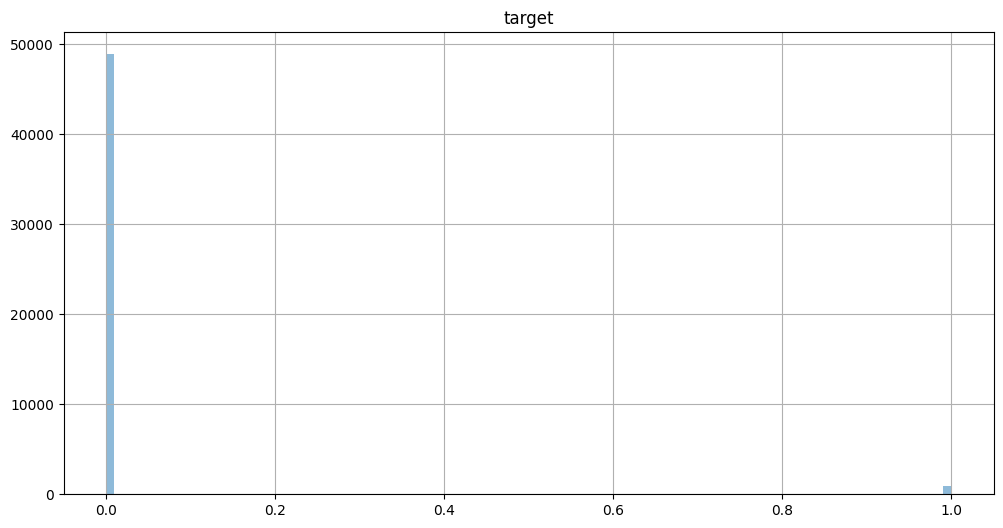

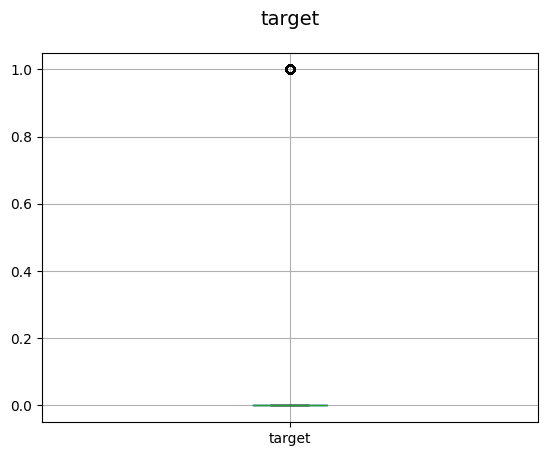

-----------------------------------------------------------
Распределение числовой величины: event.send.year.2023.count
count    49849.000000
mean        94.947020
std         74.882571
min          0.000000
25%         26.000000
50%         89.000000
75%        150.000000
max       1533.000000
Name: event.send.year.2023.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


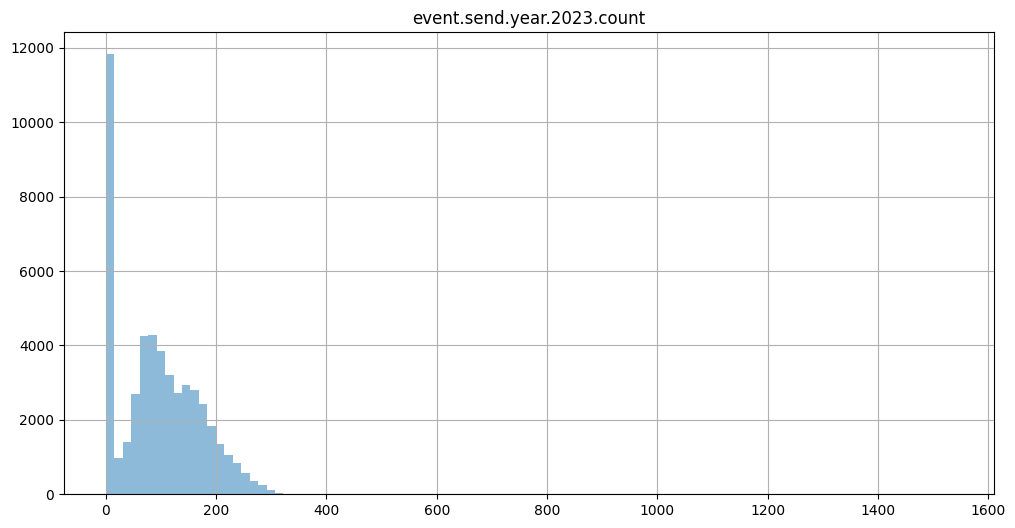

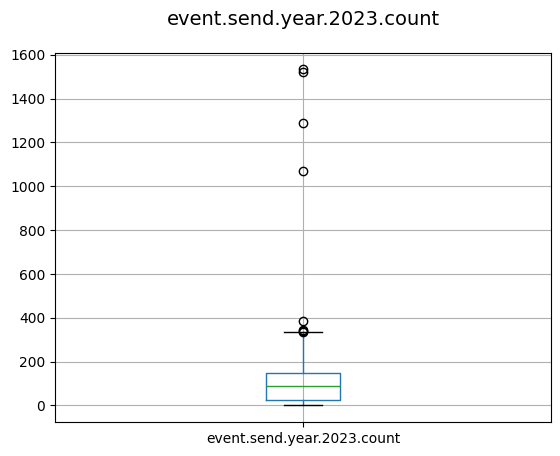

/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


-----------------------------------------------------------
Распределение числовой величины: event.send.year.2024.count
count    49849.000000
mean        19.513049
std         16.408912
min          0.000000
25%          0.000000
50%         18.000000
75%         31.000000
max        207.000000
Name: event.send.year.2024.count, dtype: float64


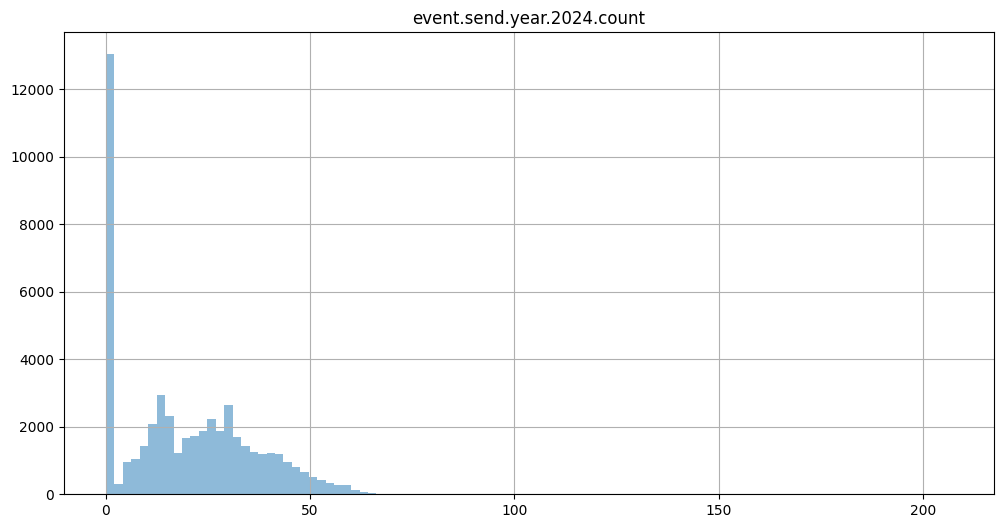

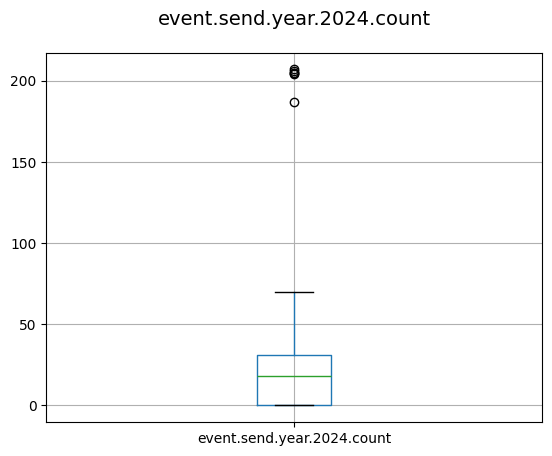

/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


-----------------------------------------------------------
Распределение числовой величины: event.positive.year.2023.count
count    49849.000000
mean         4.789183
std          8.267067
min          0.000000
25%          0.000000
50%          2.000000
75%          6.000000
max        327.000000
Name: event.positive.year.2023.count, dtype: float64


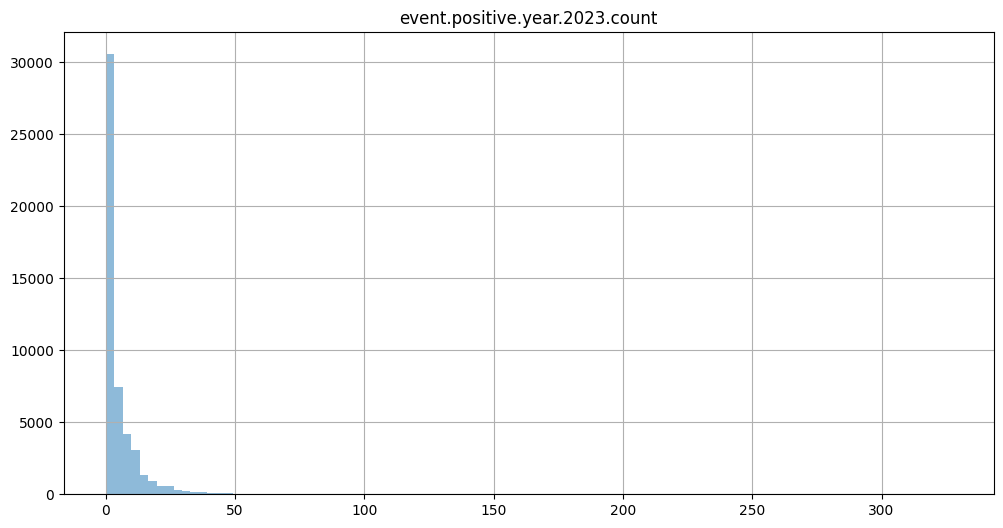

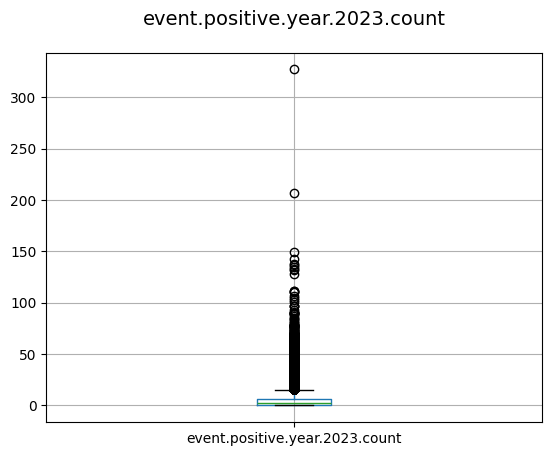

/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


-----------------------------------------------------------
Распределение числовой величины: event.positive.year.2024.count
count    49849.000000
mean         0.667717
std          2.086537
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        132.000000
Name: event.positive.year.2024.count, dtype: float64


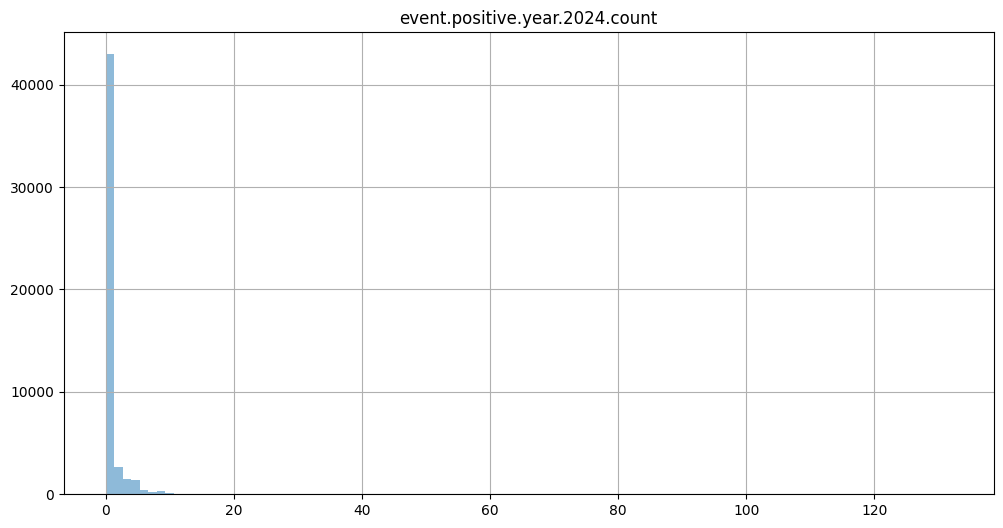

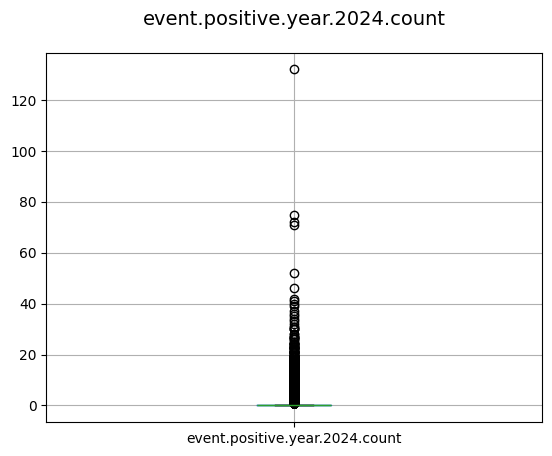

/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


-----------------------------------------------------------
Распределение числовой величины: event.negative.year.2023.count
count    49849.000000
mean         0.231479
std          0.782086
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         80.000000
Name: event.negative.year.2023.count, dtype: float64


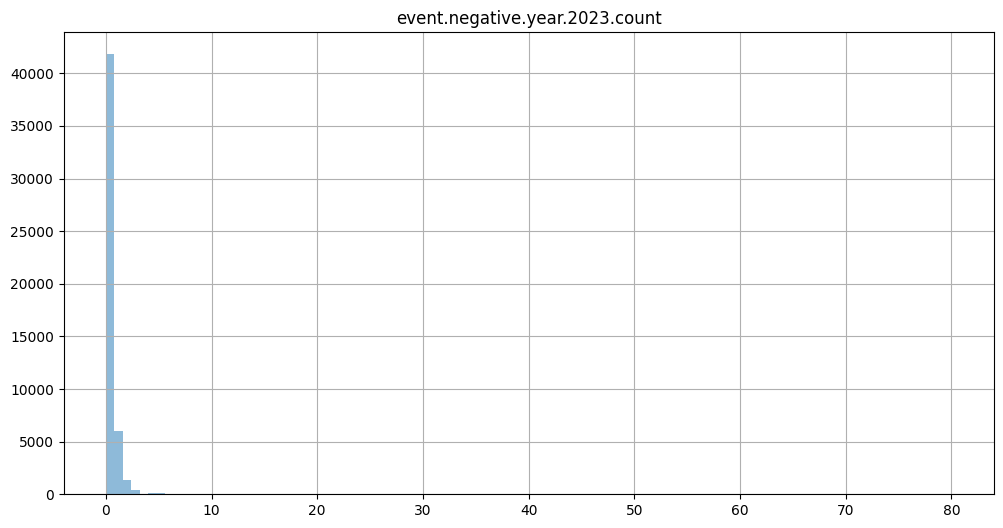

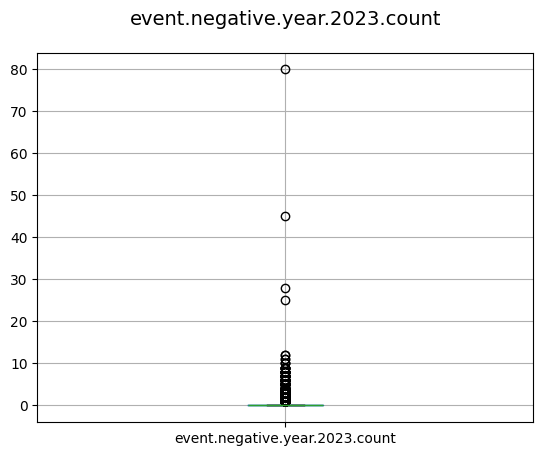

-----------------------------------------------------------
Распределение числовой величины: event.negative.year.2024.count
count    49849.000000
mean         0.052298
std          0.295701
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         35.000000
Name: event.negative.year.2024.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


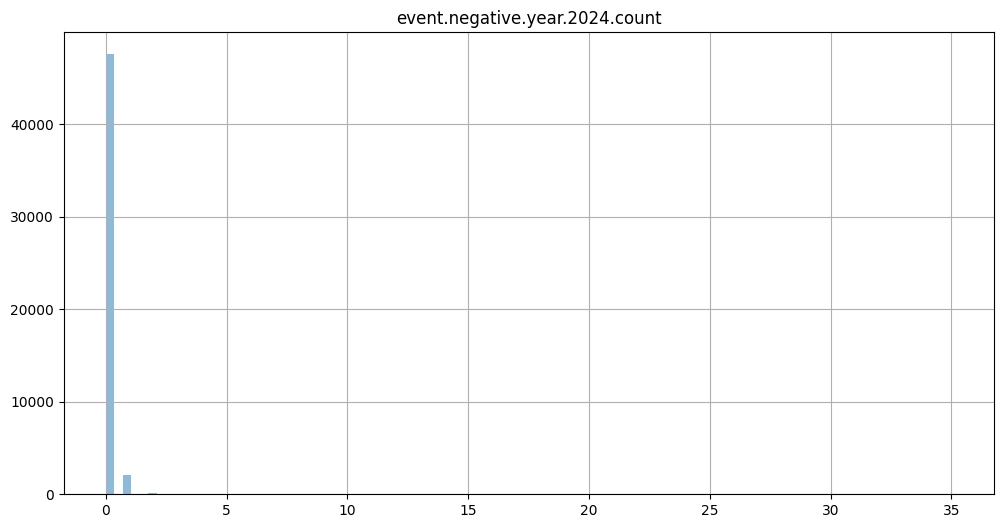

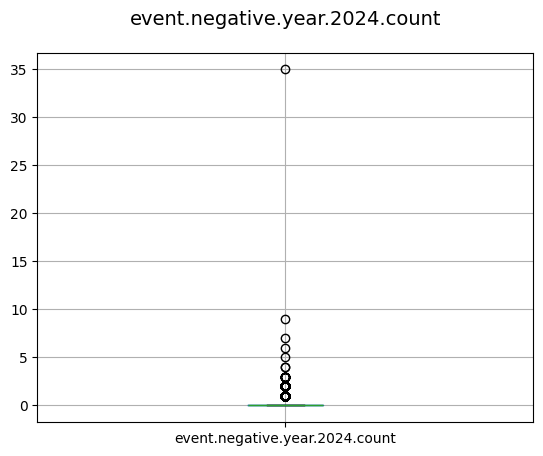

-----------------------------------------------------------
Распределение числовой величины: channel.email.year.2023.count
count    49849.000000
mean        50.013280
std         54.723446
min          0.000000
25%          0.000000
50%         38.000000
75%         94.000000
max        562.000000
Name: channel.email.year.2023.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


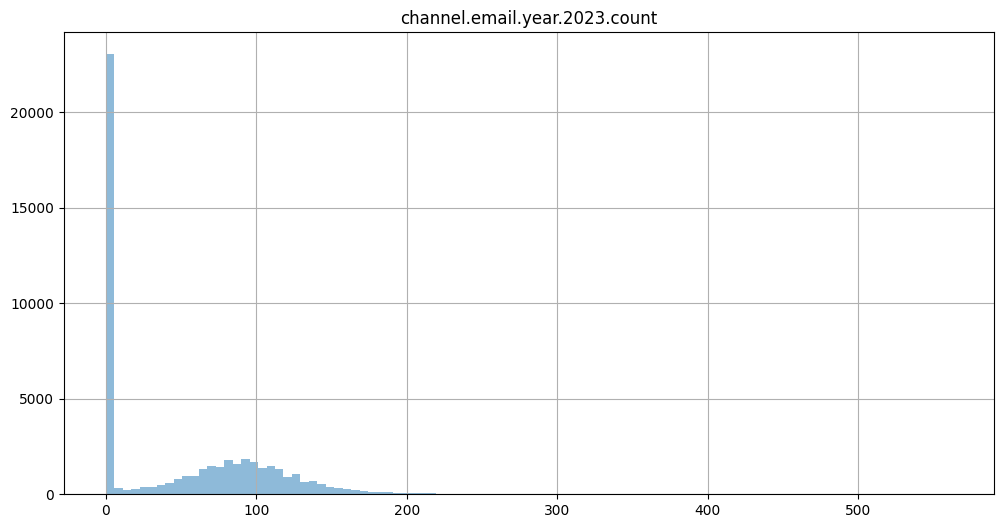

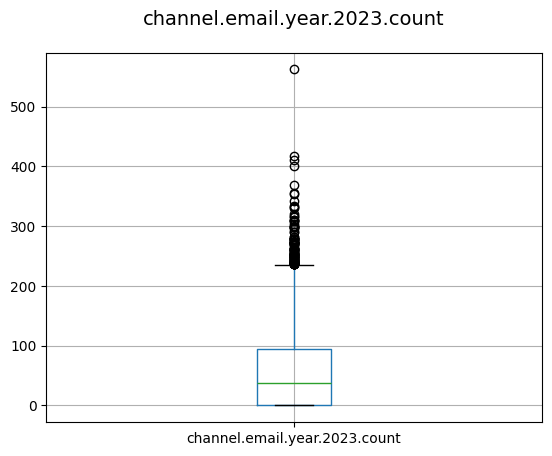

-----------------------------------------------------------
Распределение числовой величины: channel.email.year.2024.count
count    49849.000000
mean         7.745772
std          9.324995
min          0.000000
25%          0.000000
50%          0.000000
75%         15.000000
max        169.000000
Name: channel.email.year.2024.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


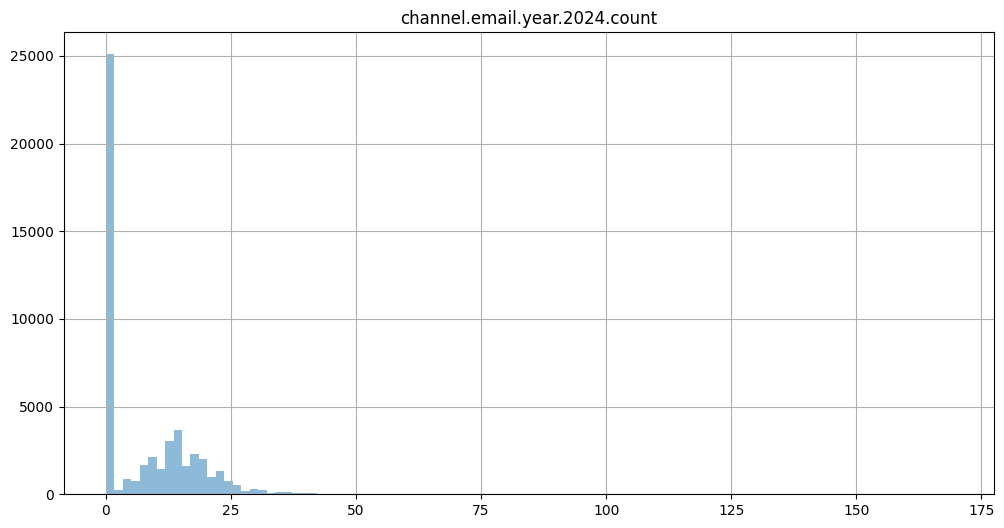

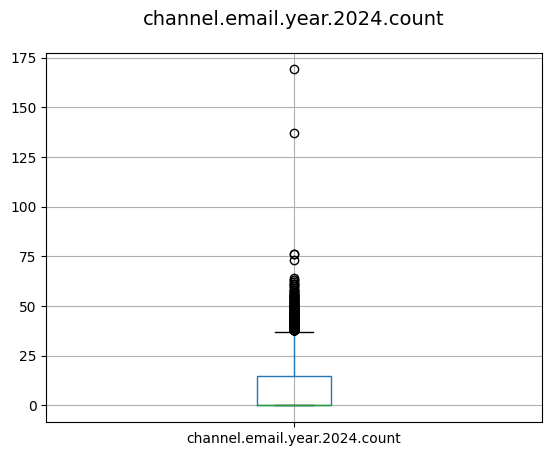

-----------------------------------------------------------
Распределение числовой величины: channel.mobile_push.year.2023.count
count    49849.000000
mean        80.471985
std         97.392530
min          0.000000
25%          0.000000
50%         37.000000
75%        146.000000
max       1910.000000
Name: channel.mobile_push.year.2023.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


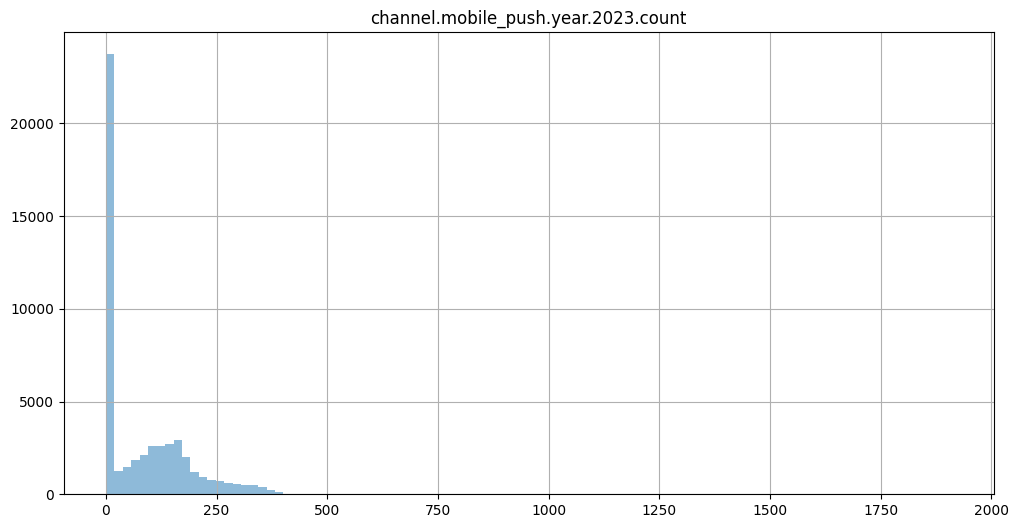

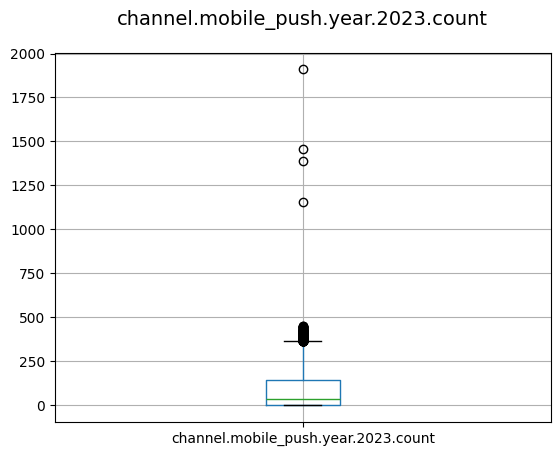

-----------------------------------------------------------
Распределение числовой величины: channel.mobile_push.year.2024.count
count    49849.000000
mean        19.025918
std         23.005376
min          0.000000
25%          0.000000
50%          2.000000
75%         32.000000
max        384.000000
Name: channel.mobile_push.year.2024.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


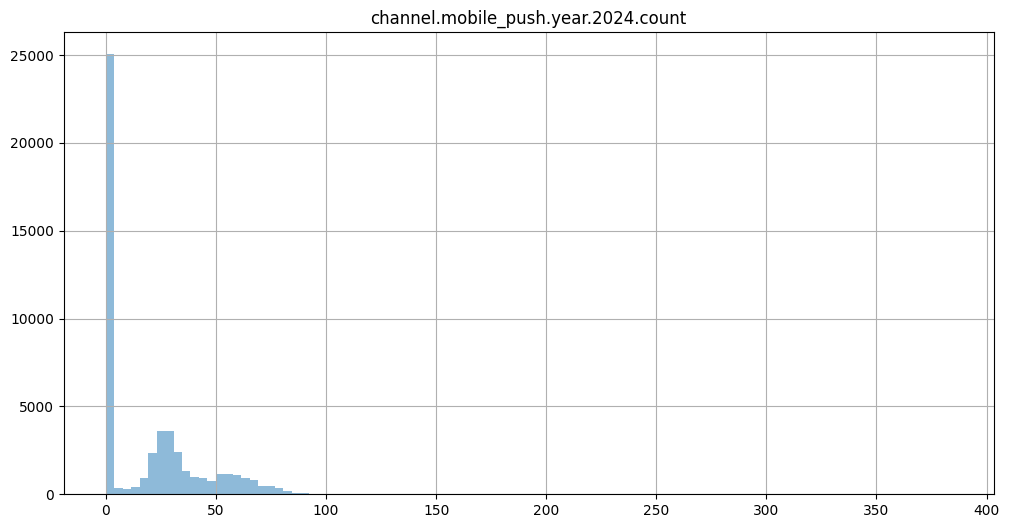

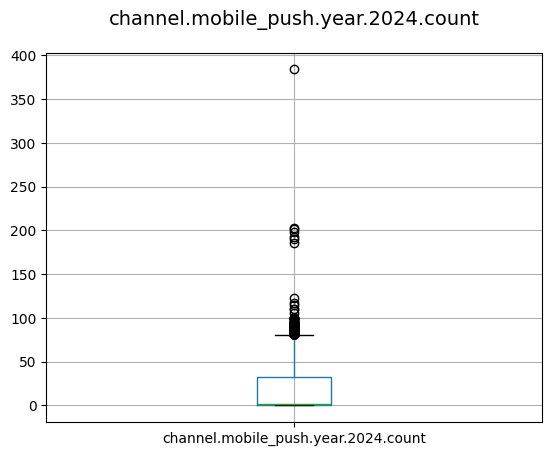

-----------------------------------------------------------
Распределение числовой величины: channel.email.purchase.year.2023.count
count    49849.000000
mean         0.274449
std          0.713999
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         57.000000
Name: channel.email.purchase.year.2023.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


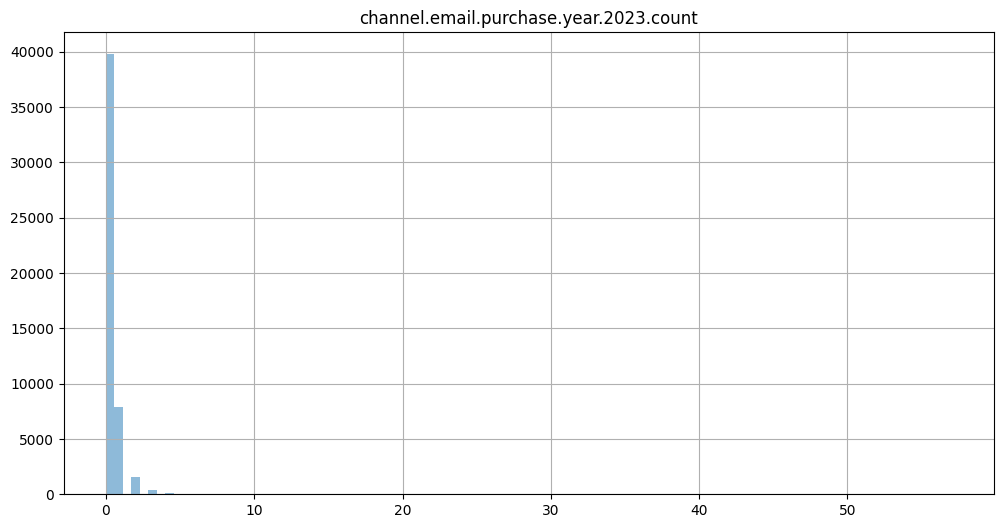

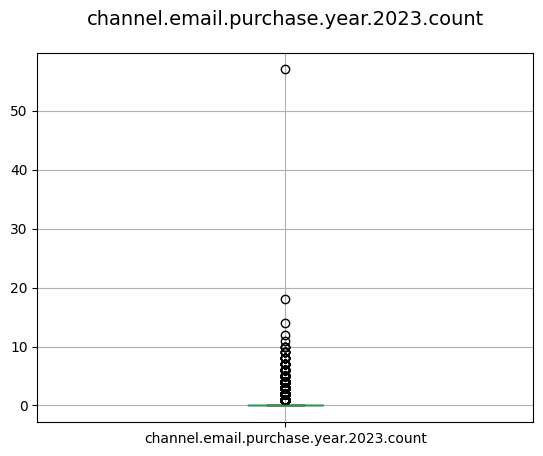

-----------------------------------------------------------
Распределение числовой величины: channel.email.purchase.year.2024.count
count    49849.000000
mean         0.006941
std          0.093265
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: channel.email.purchase.year.2024.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


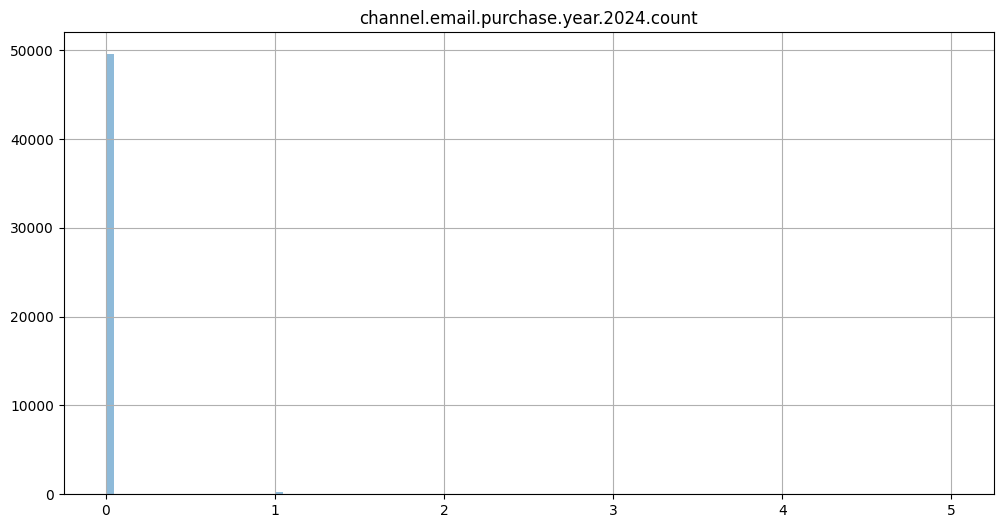

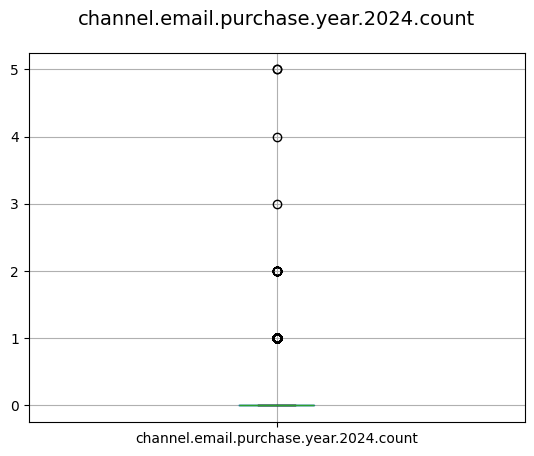

-----------------------------------------------------------
Распределение числовой величины: channel.mobile_push.purchase.year.2023.count
count    49849.000000
mean         0.186443
std          0.658287
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         75.000000
Name: channel.mobile_push.purchase.year.2023.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


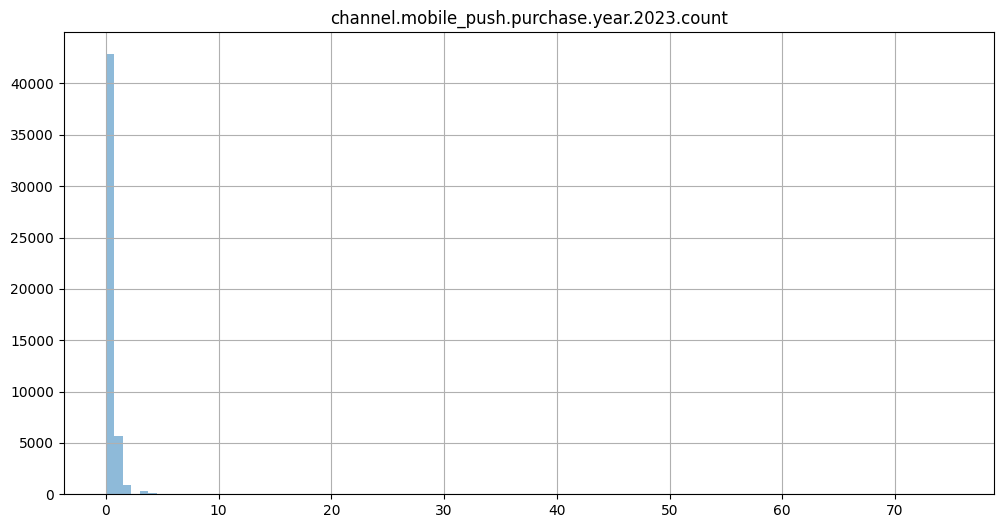

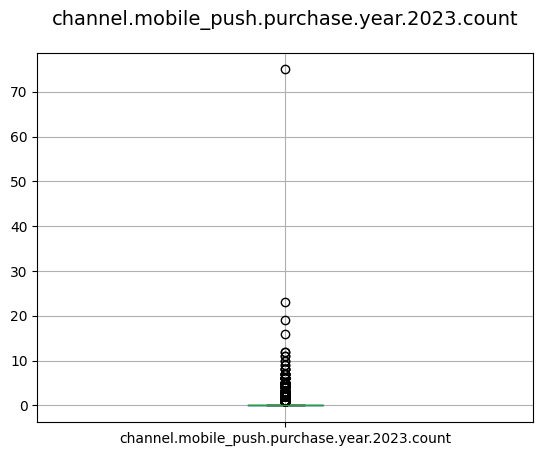

-----------------------------------------------------------
Распределение числовой величины: channel.mobile_push.purchase.year.2024.count
count    49849.000000
mean         0.038556
std          0.222955
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: channel.mobile_push.purchase.year.2024.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


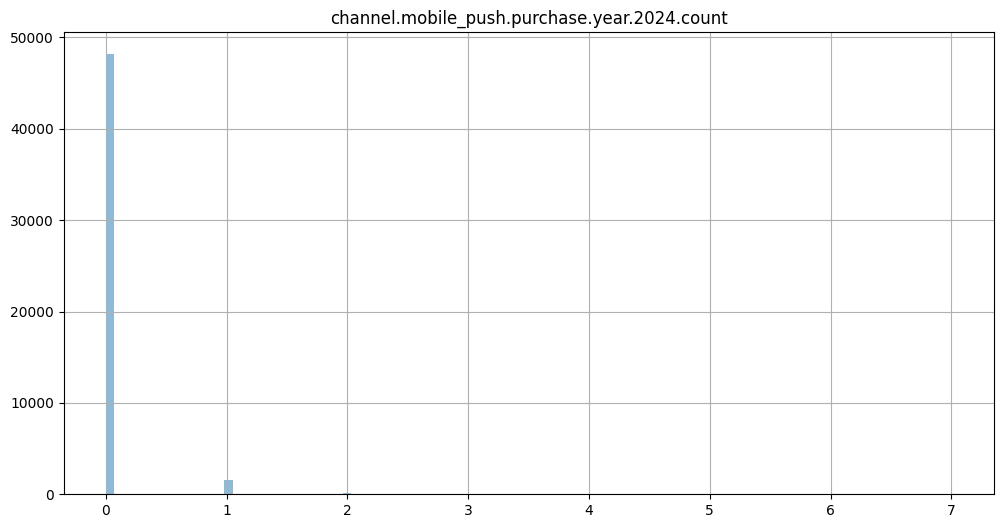

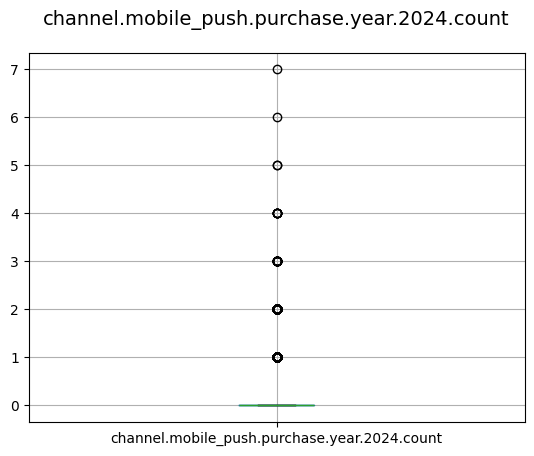

-----------------------------------------------------------
Распределение числовой величины: quantity.year.2023.sum
count    49849.000000
mean         1.316757
std          2.420243
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        105.000000
Name: quantity.year.2023.sum, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


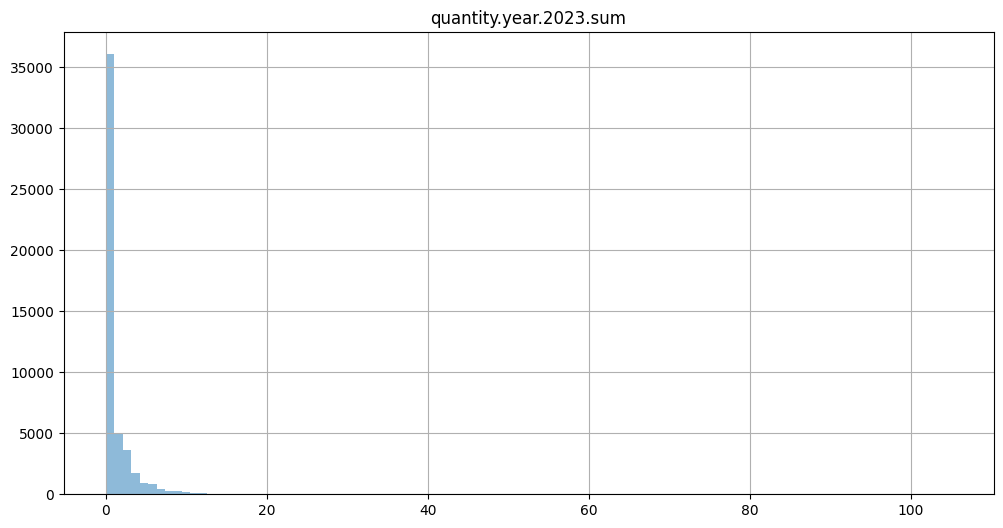

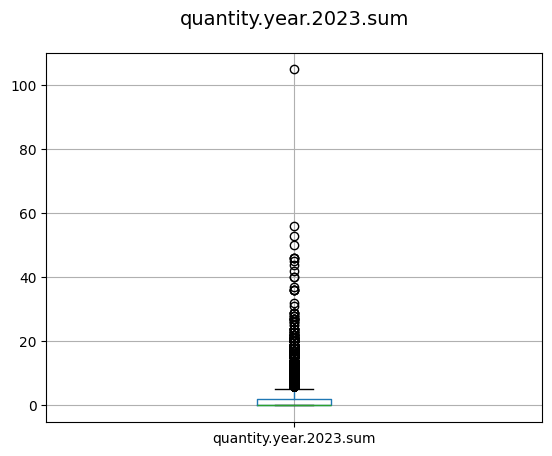

-----------------------------------------------------------
Распределение числовой величины: quantity.year.2023.median
count    49849.000000
mean         0.496078
std          0.518147
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         18.000000
Name: quantity.year.2023.median, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


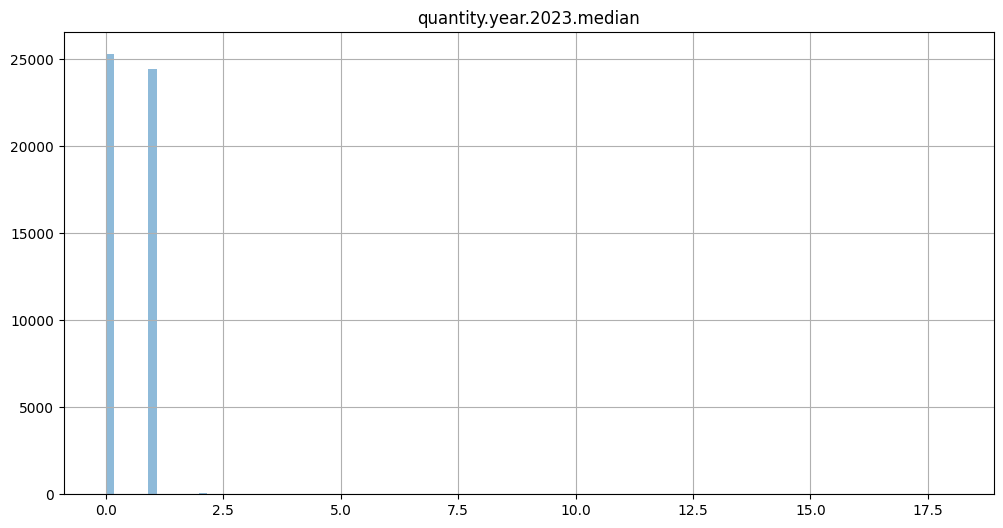

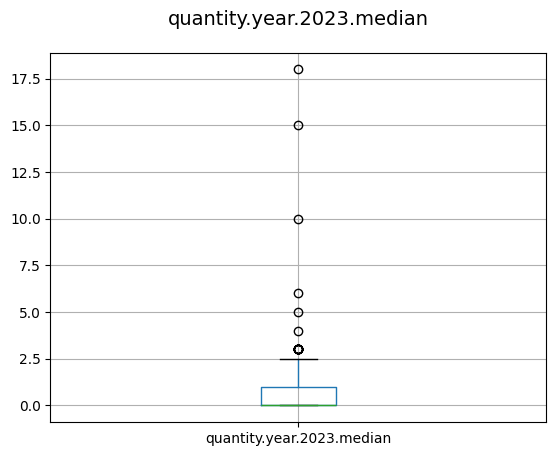

/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


-----------------------------------------------------------
Распределение числовой величины: quantity.year.2024.sum
count    49849.000000
mean         0.132580
std          0.822064
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         36.000000
Name: quantity.year.2024.sum, dtype: float64


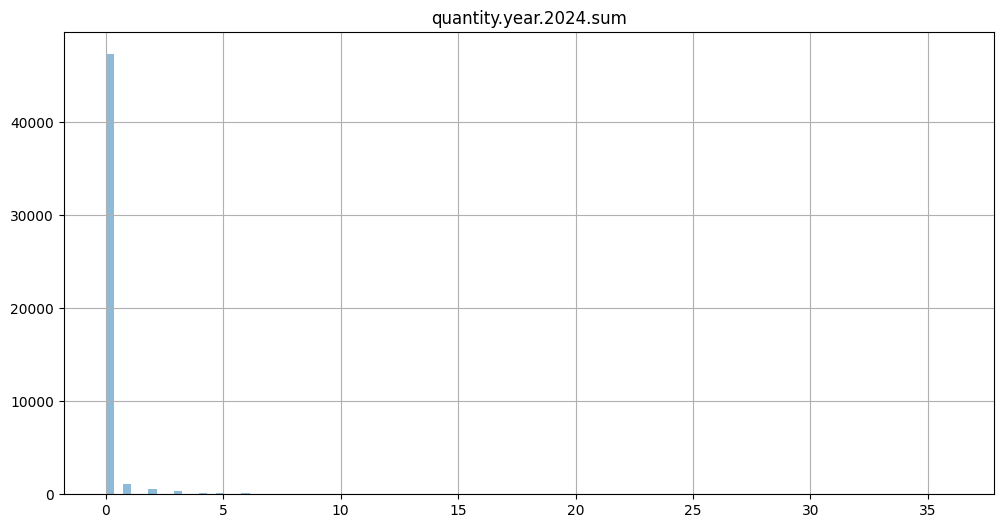

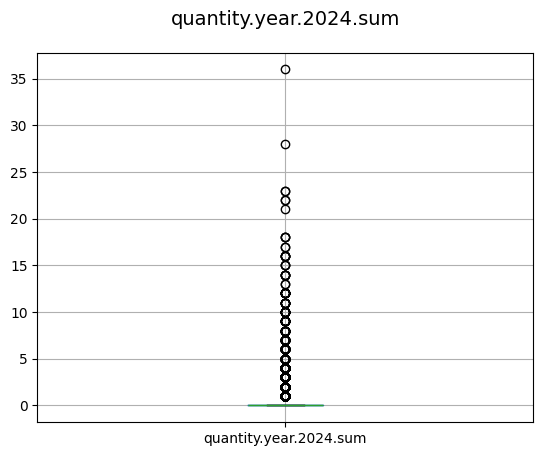

-----------------------------------------------------------
Распределение числовой величины: quantity.year.2024.median
count    49849.000000
mean         0.050633
std          0.219820
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: quantity.year.2024.median, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


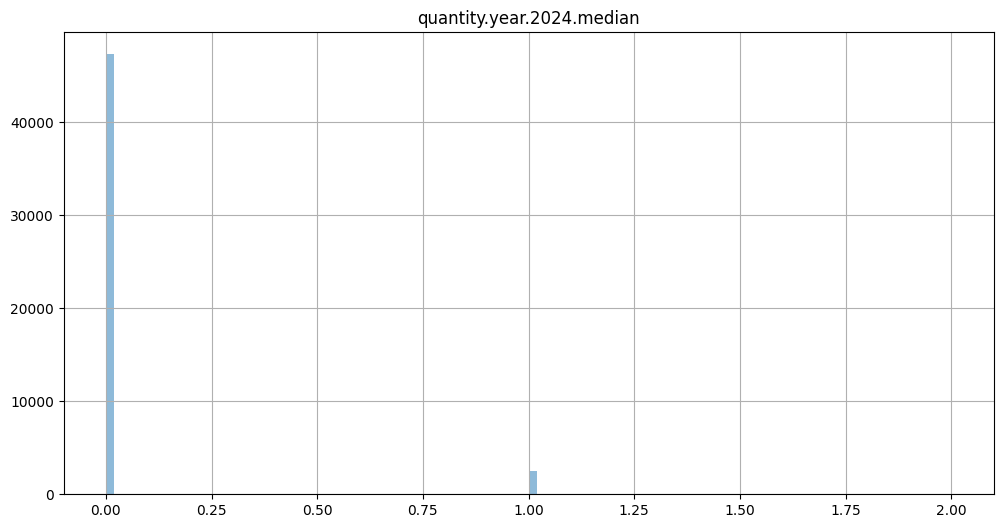

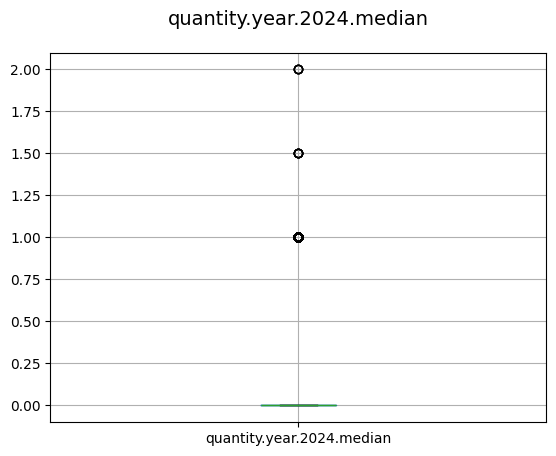

-----------------------------------------------------------
Распределение числовой величины: price.year.2023.sum
count     49849.000000
mean       1517.564926
std        3461.366215
min           0.000000
25%           0.000000
50%           0.000000
75%        1999.000000
max      297954.000000
Name: price.year.2023.sum, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


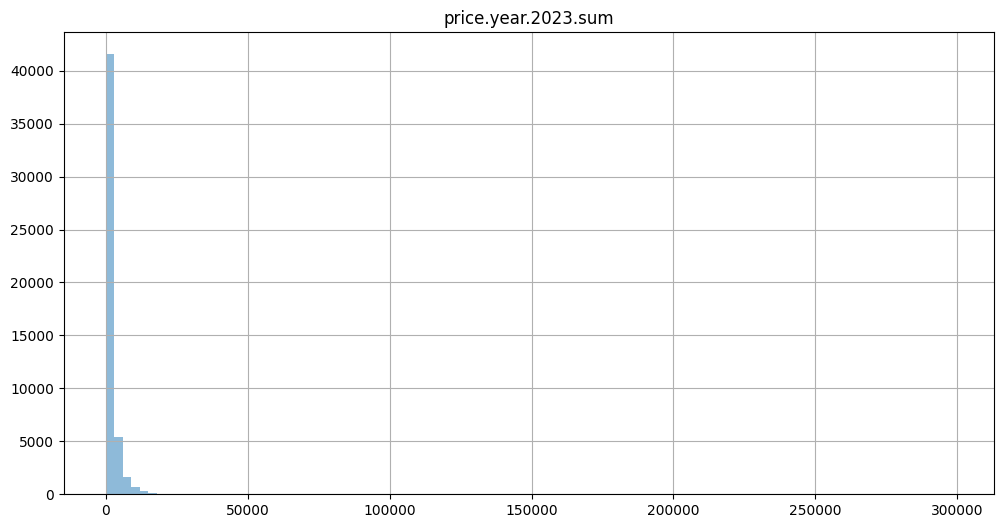

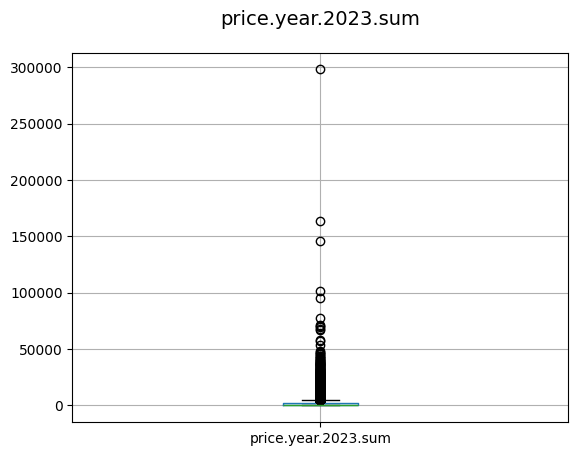

-----------------------------------------------------------
Распределение числовой величины: price.year.2023.median
count    49849.000000
mean       674.015537
std       1219.182230
min          0.000000
25%          0.000000
50%          0.000000
75%       1049.000000
max      53499.000000
Name: price.year.2023.median, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


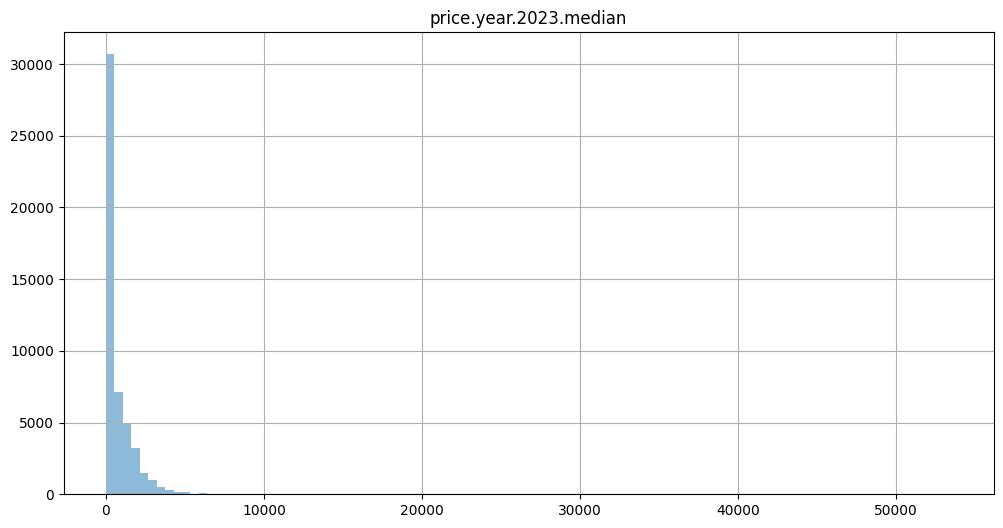

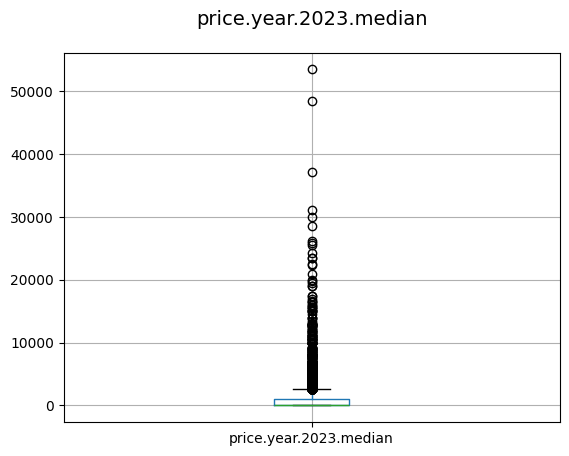

-----------------------------------------------------------
Распределение числовой величины: price.year.2024.sum
count     49849.000000
mean        171.221389
std        1478.883289
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      159687.000000
Name: price.year.2024.sum, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


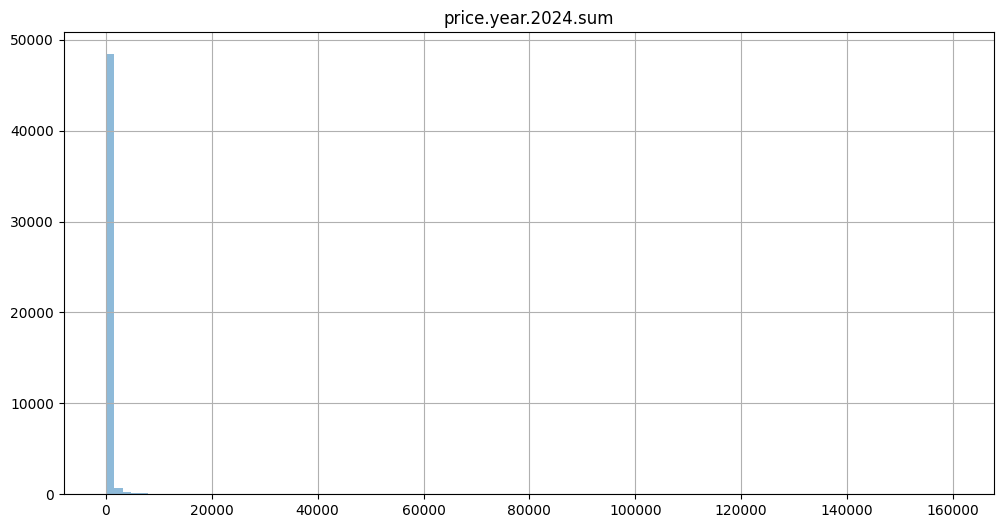

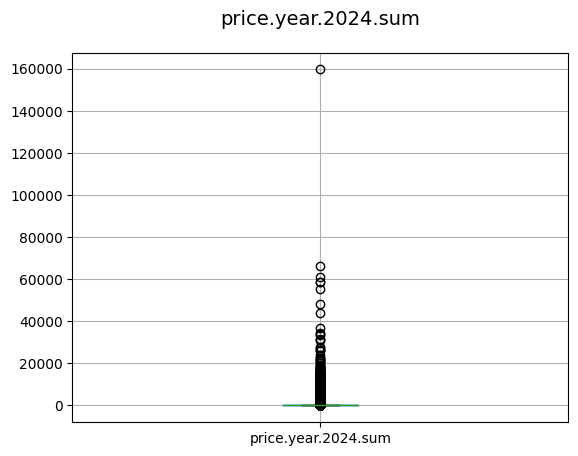

-----------------------------------------------------------
Распределение числовой величины: price.year.2024.median
count    49849.000000
mean        76.246063
std        561.265336
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      48299.000000
Name: price.year.2024.median, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


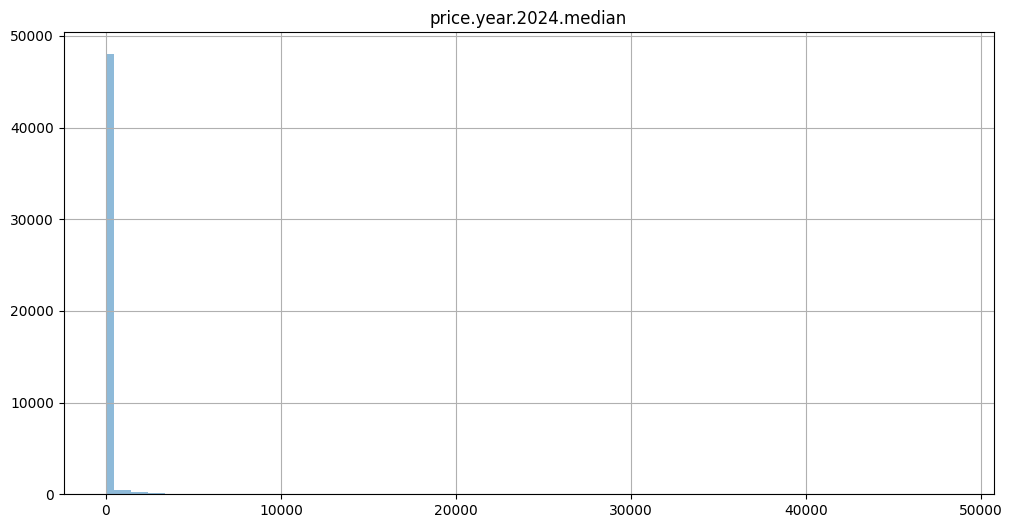

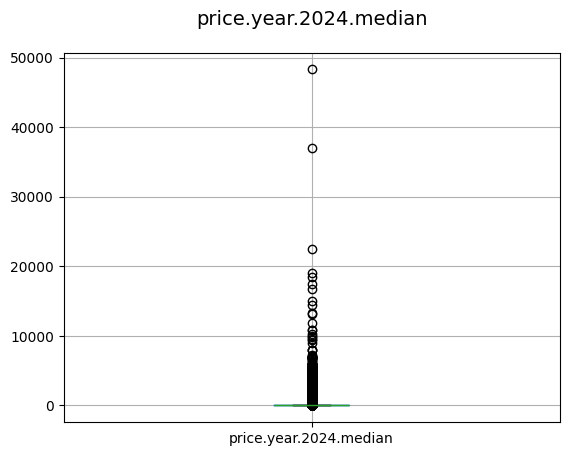

-----------------------------------------------------------
Распределение числовой величины: category_ids.count
count    49849.000000
mean         6.018315
std          3.815566
min          0.000000
25%          4.000000
50%          4.000000
75%          7.000000
max         87.000000
Name: category_ids.count, dtype: float64


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


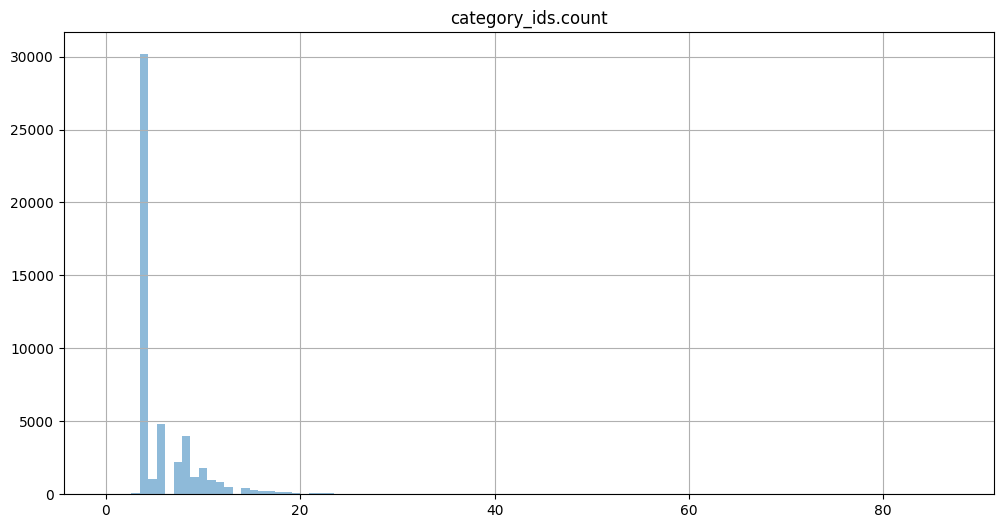

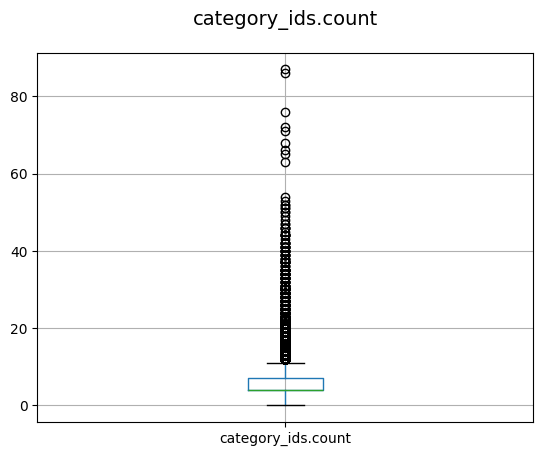

-----------------------------------------------------------
Распределение категориальной величины: category_ids.mode.first


/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


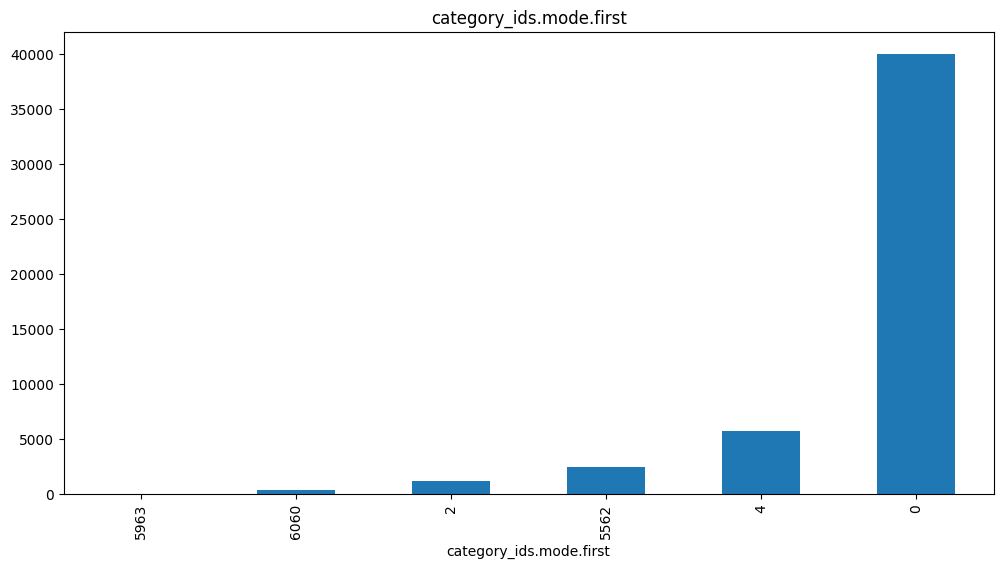

/tmp/ipykernel_14977/449389165.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_object_dtype(dataframe[column]):


-----------------------------------------------------------
Распределение категориальной величины: category_ids.mode.last


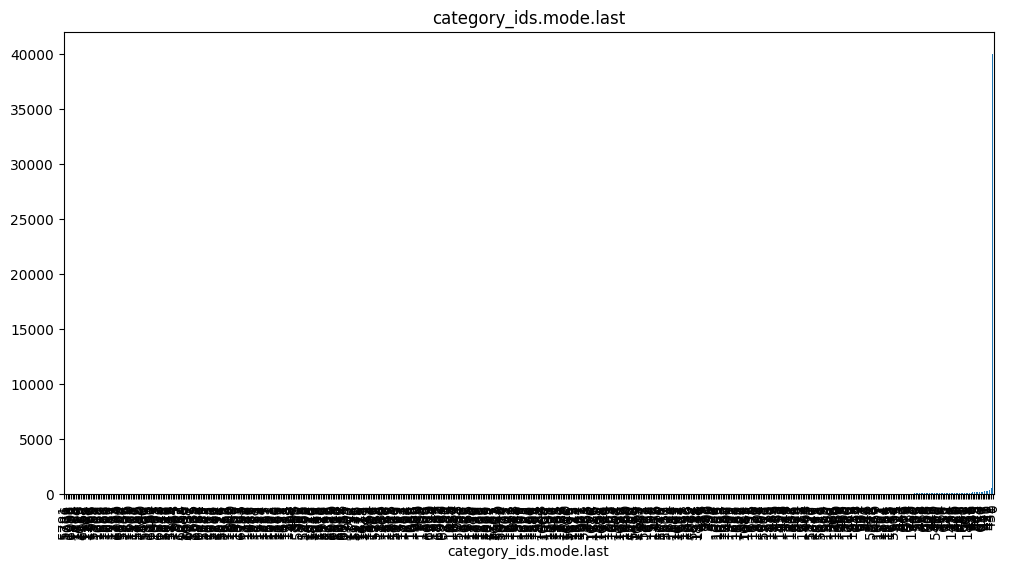

In [290]:
visualize(df_cleaned)

In [291]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 27 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   client_id                                     49849 non-null  int64  
 1   target                                        49849 non-null  int64  
 2   event.send.year.2023.count                    49849 non-null  float64
 3   event.send.year.2024.count                    49849 non-null  float64
 4   event.positive.year.2023.count                49849 non-null  float64
 5   event.positive.year.2024.count                49849 non-null  float64
 6   event.negative.year.2023.count                49849 non-null  float64
 7   event.negative.year.2024.count                49849 non-null  float64
 8   channel.email.year.2023.count                 49849 non-null  float64
 9   channel.email.year.2024.count                 49849 non-null 

### Для экономии памяти

In [292]:
columns_exceptions = [
    'client_id',
    'category_ids.mode.first',
    'category_ids.mode.last'
]

float_32_cloumns = [
    'price.year.2023.sum',
    'price.year.2023.median',
    'price.year.2024.sum',
    'price.year.2024.median'
]

for column in df_cleaned.columns:
    if column not in columns_exceptions+float_32_cloumns:
        df_cleaned[column] = df_cleaned[column].astype(np.int32)
    elif column in float_32_cloumns:
        df_cleaned[column] = df_cleaned[column].astype(np.float32)

In [293]:
df_cleaned['category_ids.mode.first'] = df_cleaned['category_ids.mode.first'].astype(str)
df_cleaned['category_ids.mode.last']  = df_cleaned['category_ids.mode.last'].astype(str)

In [294]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 27 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   client_id                                     49849 non-null  int64  
 1   target                                        49849 non-null  int32  
 2   event.send.year.2023.count                    49849 non-null  int32  
 3   event.send.year.2024.count                    49849 non-null  int32  
 4   event.positive.year.2023.count                49849 non-null  int32  
 5   event.positive.year.2024.count                49849 non-null  int32  
 6   event.negative.year.2023.count                49849 non-null  int32  
 7   event.negative.year.2024.count                49849 non-null  int32  
 8   channel.email.year.2023.count                 49849 non-null  int32  
 9   channel.email.year.2024.count                 49849 non-null 

In [295]:
df_cleaned = df_cleaned.rename(columns={
    'event.send.year.2023.count': 'ev.send.23.c',
    'event.send.year.2024.count': 'ev.send.24.c',
    'event.positive.year.2023.count': 'ev.pos.23.c',
    'event.positive.year.2024.count': 'ev.pos.24.c',
    'event.negative.year.2023.count': 'ev.neg.23.c',
    'event.negative.year.2024.count': 'ev.neg.24.c',
    'channel.email.year.2023.count': 'ch.email.23.c',
    'channel.email.year.2024.count': 'ch.email.24.c',
    'channel.mobile_push.year.2023.count': 'ch.push.23.c',
    'channel.mobile_push.year.2024.count': 'ch.push.24.c',
    'channel.email.purchase.year.2023.count': 'ch.email.purch.23.c',
    'channel.email.purchase.year.2024.count': 'ch.email.purch.24.c',
    'channel.mobile_push.purchase.year.2023.count': 'ch.push.purch.23.c',
    'channel.mobile_push.purchase.year.2024.count': 'ch.push.purch.24.c',
    'quantity.year.2023.sum': 'qty.23.sum',
    'quantity.year.2023.median': 'qty.23.med',
    'quantity.year.2024.sum': 'qty.24.sum',
    'quantity.year.2024.median': 'qty.24.med',
    'price.year.2023.sum': 'pr.23.sum',
    'price.year.2023.median': 'pr.23.med',
    'price.year.2024.sum': 'pr.24.sum',
    'price.year.2024.median': 'pr.24.med',
    'category_ids.count': 'cat.c',
    'category_ids.mode.first': 'cat.mod.fst',
    'category_ids.mode.last': 'cat.mod.lst'
})

In [296]:
# числовые данные
id_columns    = ['client_id']
interval_cols = [
    'ev.send.23.c',
    'ev.send.24.c',
    'ev.pos.23.c',
    'ev.pos.23.c',
    'ev.neg.23.c',
    'ev.neg.24.c',
    'ch.email.23.c',
    'ch.email.24.c',
    'ch.push.23.c',
    'ch.push.24.c',
    'ch.email.purch.23.c',
    'ch.email.purch.24.c',
    'ch.push.purch.23.c',
    'ch.push.purch.24.c',
    'qty.23.sum',
    'qty.23.med',
    'qty.24.sum',
    'qty.24.med',
    'pr.23.sum',
    'pr.23.med',
    'pr.24.sum',
    'pr.24.med',
    'cat.c'
]

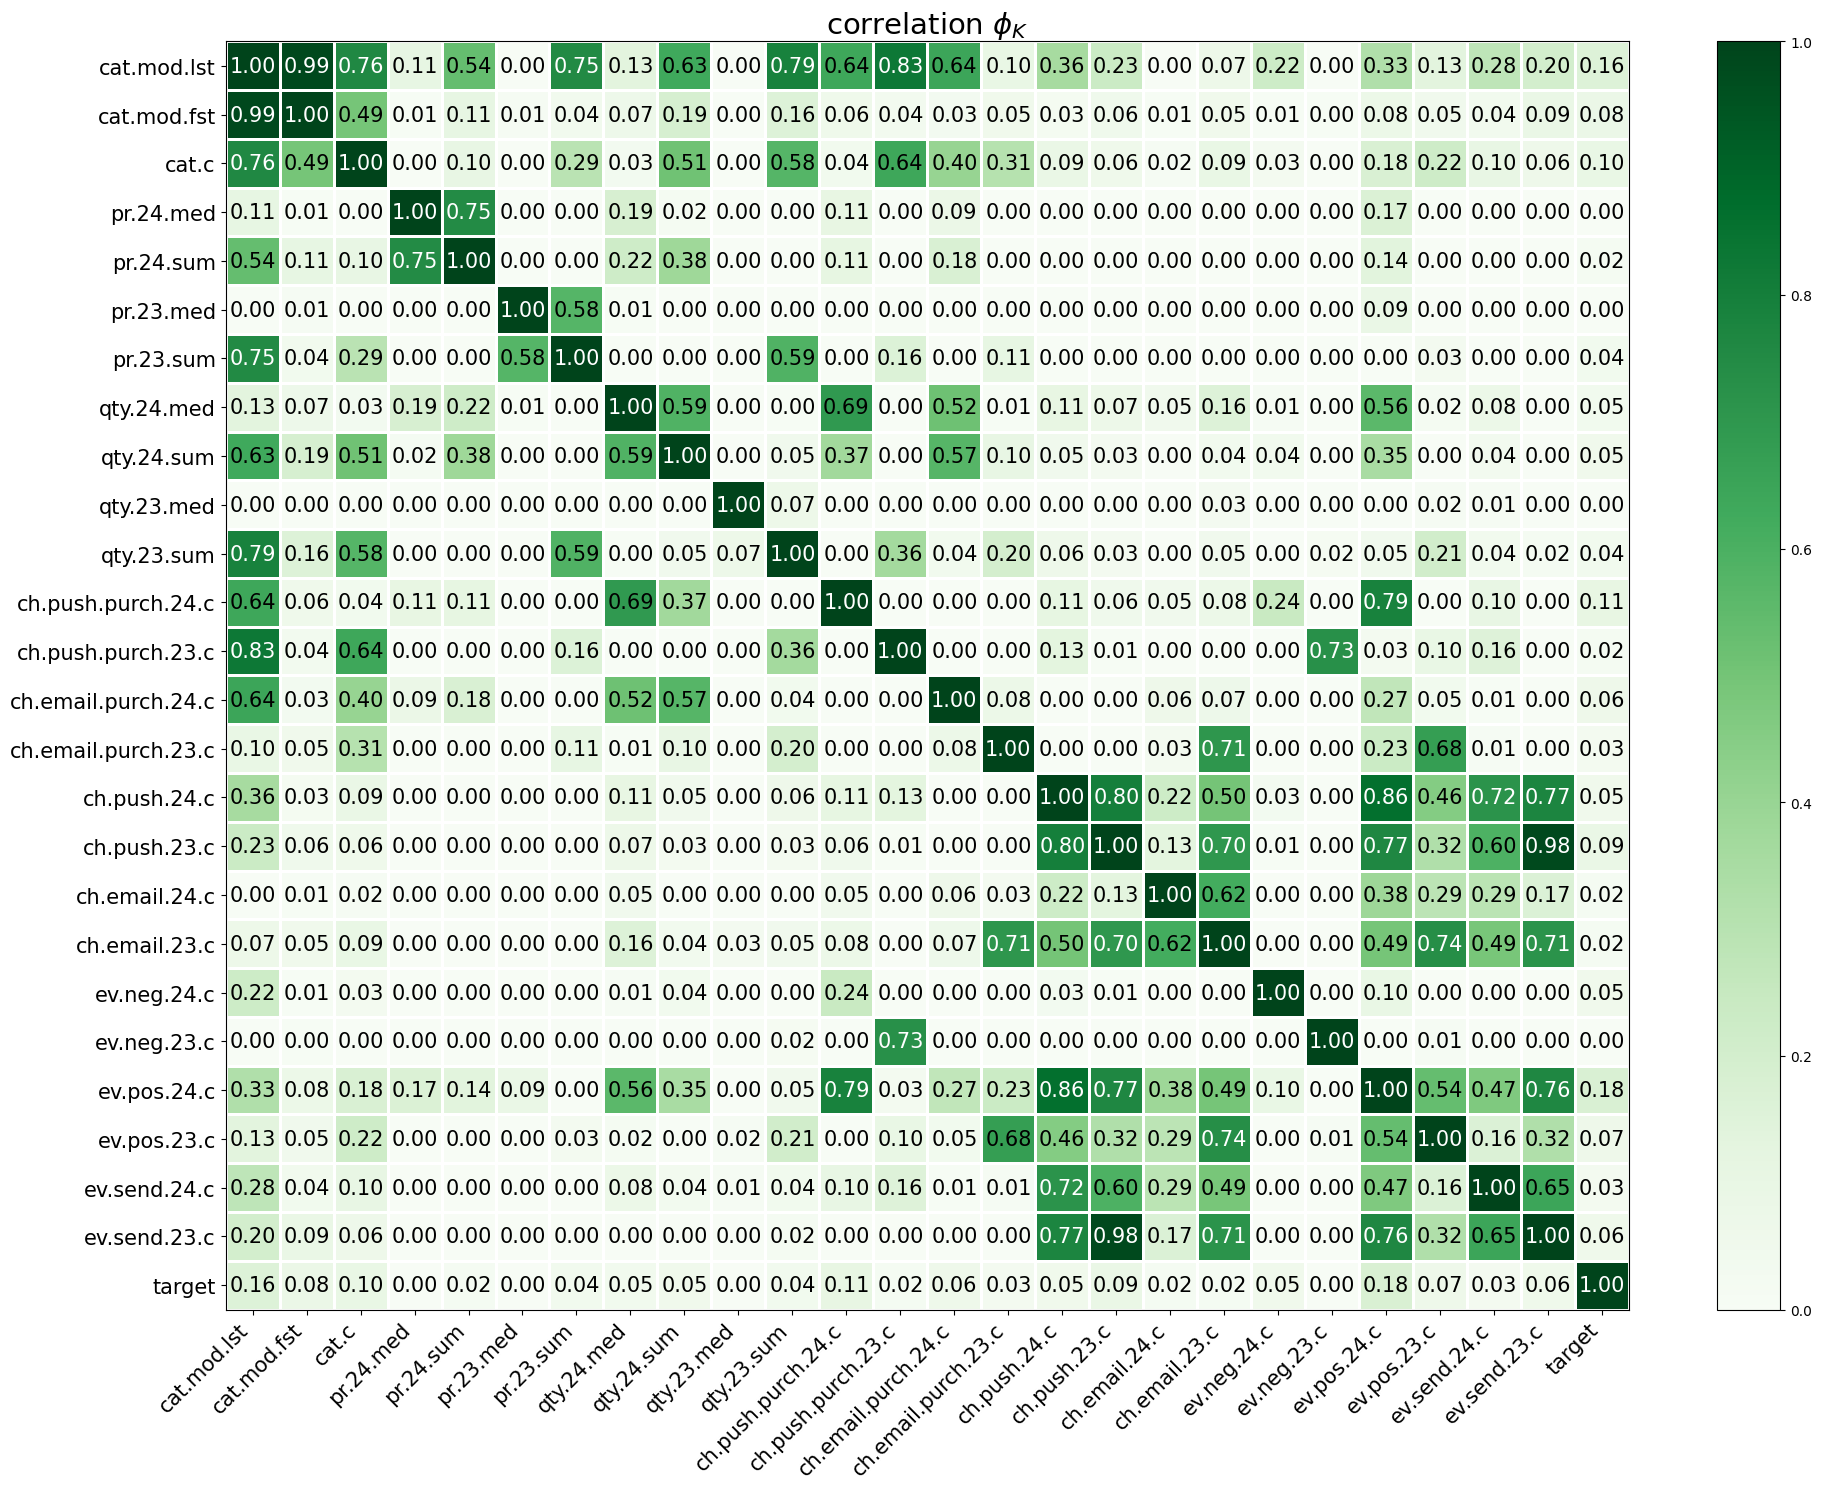

In [297]:
phik_overview = phik_matrix(df_cleaned.drop(columns=id_columns), interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Заметки**

 - `cat.mod.fst` и `cat.mod.lst` - высокая коллинеарность, скорее всего потому, что категория нижнего уровня зависит от категории верхнего уровня, оставлю более специфичную `cat.mod.lst`, менее специфичную удалю `cat.mod.fst`
 - `ev.send.23.c` и `ch.push.23.c` высокая коллинеарность, аналогично все события send должны быть доставлены либо через push либо через email, удалю менее специфичную категорию `ev.send.23.c`.

In [298]:
df_cleaned = df_cleaned.drop(columns=[
    'cat.mod.fst',
    'ev.send.23.c',
    'ev.send.24.c',
    'ch.push.purch.23.c',
    'ch.push.purch.24.c',
    'ch.email.purch.23.c',
    'ch.email.purch.24.c',
    'ev.pos.23.c',
    'ev.pos.24.c',
    'qty.23.med',
    'qty.24.med',
    'pr.23.med',
    'pr.24.med',
    'ch.push.23.c',
    'ch.push.24.c',
    'ch.email.23.c',
    'ch.email.24.c',
])

In [299]:
# числовые данные
id_columns    = ['client_id']
interval_cols = [
    # 'ev.send.23.c',
    # 'ev.send.24.c',
    # 'ev.pos.23.c',
    # 'ev.pos.24.c',
    'ev.neg.23.c',
    'ev.neg.24.c',
    # 'ch.email.23.c',
    # 'ch.email.24.c',
    # 'ch.push.23.c',
    # 'ch.push.24.c',
    # 'ch.email.purch.23.c',
    # 'ch.email.purch.24.c',
    # 'ch.push.purch.23.c',
    # 'ch.push.purch.24.c',
    'qty.23.sum',
    # 'qty.23.med',
    'qty.24.sum',
    # 'qty.24.med',
    'pr.23.sum',
    # 'pr.23.med',
    'pr.24.sum',
    # 'pr.24.med',
    'cat.c'
]

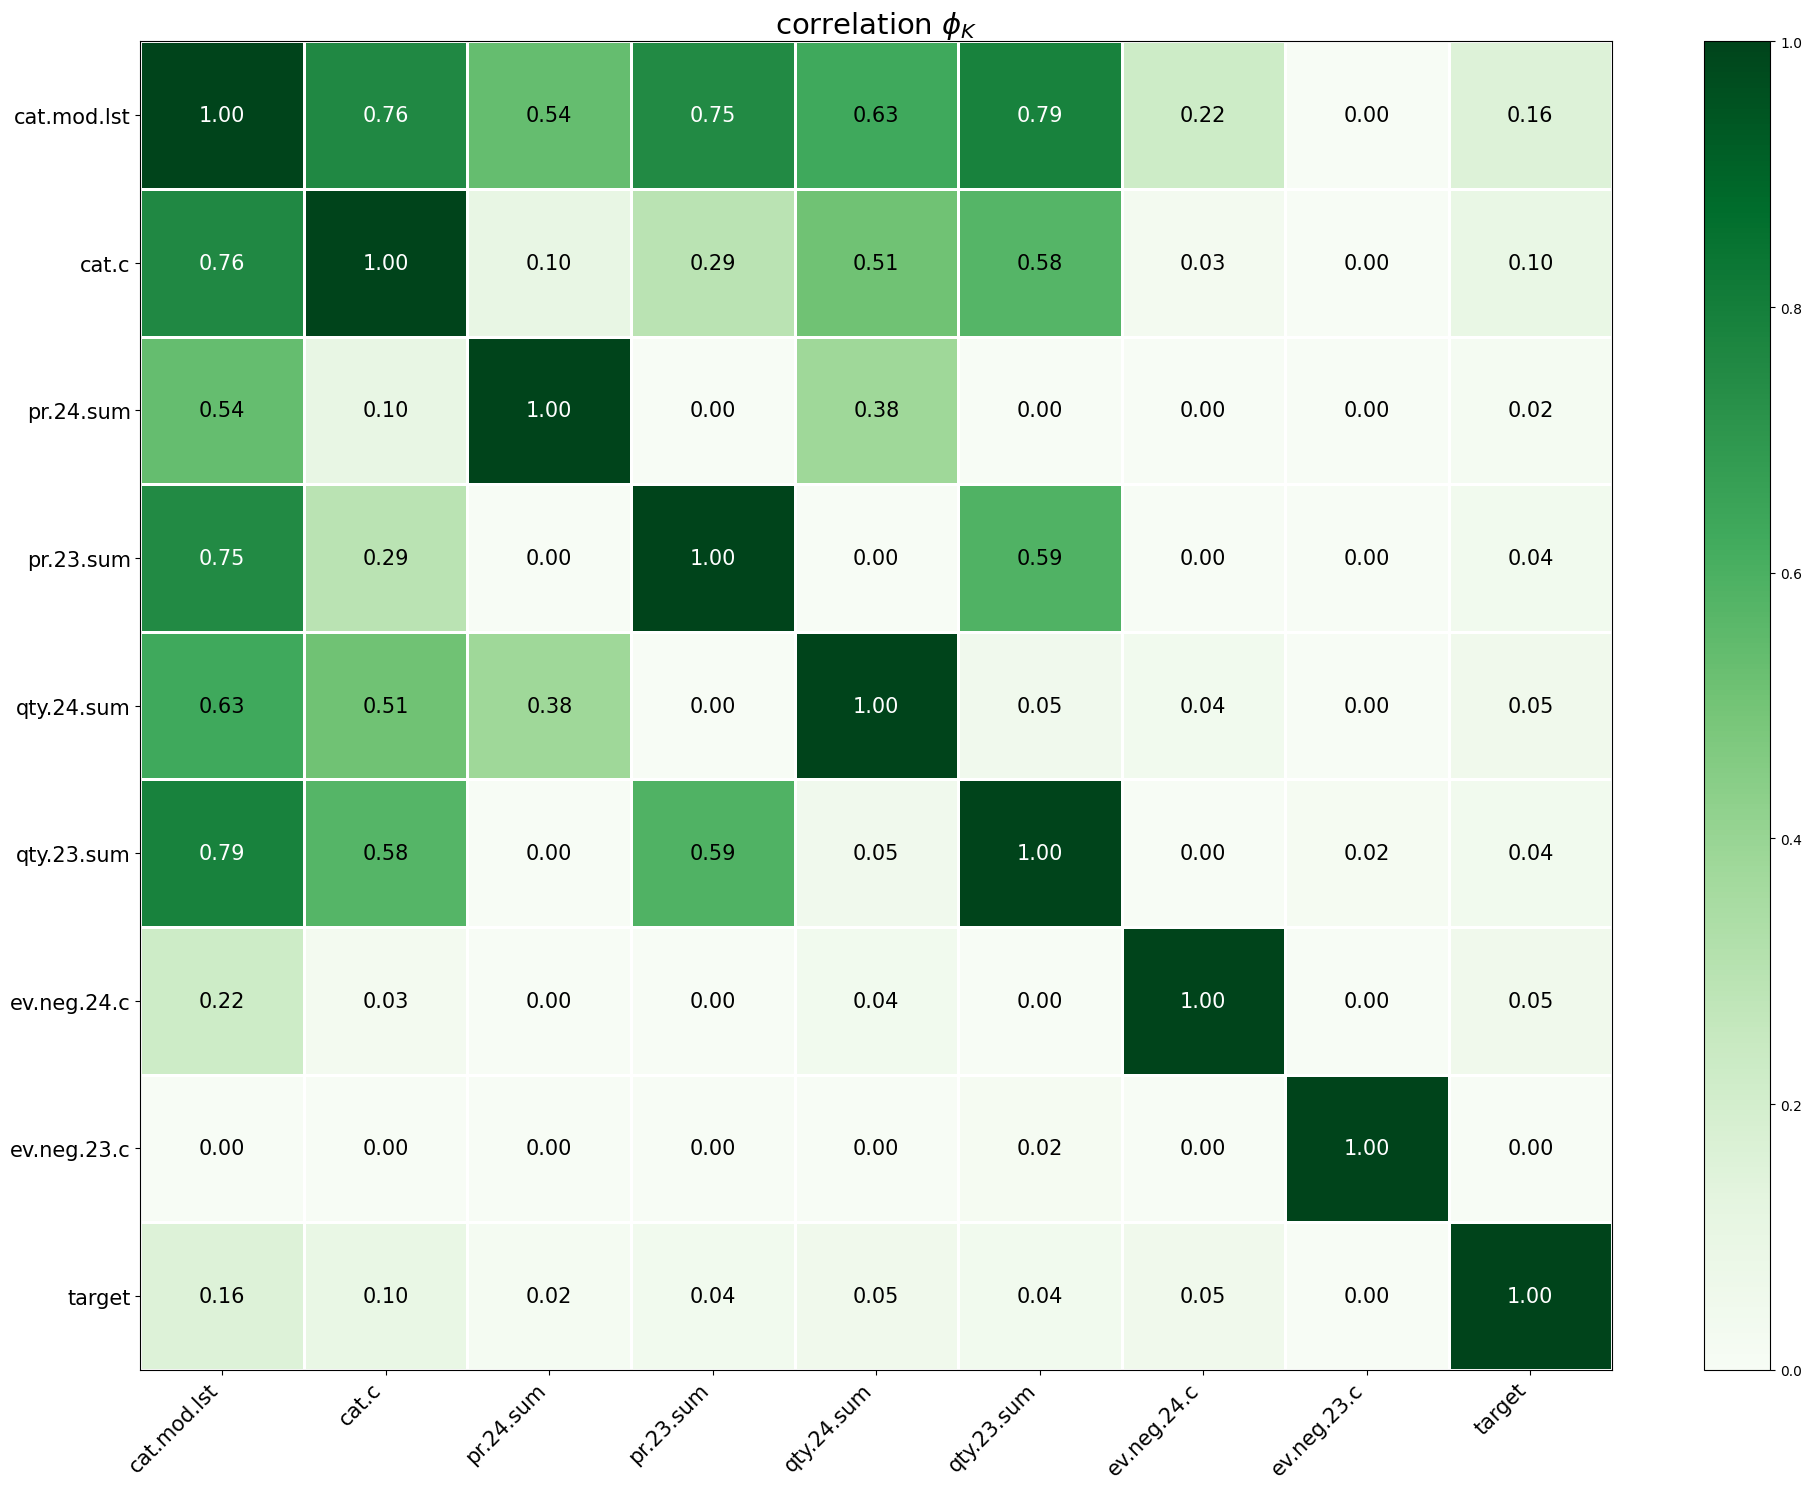

In [300]:
phik_overview = phik_matrix(df_cleaned.drop(columns=id_columns), interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Обучение модели

In [301]:
target_feature = 'target'

ohe_columns = [
    'cat.mod.lst'
]

num_columns = [
    # 'ev.send.24.c',
    # 'ev.pos.23.c',
    # 'ev.pos.23.c',
    'ev.neg.23.c',
    'ev.neg.24.c',
    # 'ch.email.23.c',
    # 'ch.email.24.c',
    # 'ch.push.23.c',
    # 'ch.push.24.c',
    # 'ch.email.purch.23.c',
    # 'ch.email.purch.24.c',
    # 'ch.push.purch.23.c',
    # 'ch.push.purch.24.c',
    'qty.23.sum',
    # 'qty.23.med',
    'qty.24.sum',
    # 'qty.24.med',
    'pr.23.sum',
    # 'pr.23.med',
    'pr.24.sum',
    # 'pr.24.med',
    'cat.c'
]

drop_features = ['client_id']

In [302]:
ohe_pipe = Pipeline(
    [
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        )
    ]
)

In [303]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [304]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', CatBoostClassifier(random_state=RANDOM_STATE))
])

In [305]:
# создаём словарь с гиперпараметрами для каждой модели
param_grid = [
    # {
    #     'models': [CatBoostClassifier(
    #         random_state=RANDOM_STATE
    #     )],
    #     'models__n_estimators': [10, 20],
    # },
    {
        'models': [RandomForestClassifier(
            random_state=RANDOM_STATE
        )],
        'models__n_estimators': [100],
        'models__max_depth': [10]
    },
]

In [306]:
X_train, X_test, y_train, y_test = train_test_split(
    df_cleaned.drop(drop_features, axis=1),
    df_cleaned[target_feature], 
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE
)

In [307]:
X_train.shape, y_train.shape

((37386, 9), (37386,))

In [308]:
X_test.shape, y_test.shape

((12463, 9), (12463,))

In [309]:
grid = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1
)

In [310]:
grid.fit(X_train, y_train)

/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/n1654/jupyter-notebook/jupyter-env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warning

,estimator,Pipeline(step...59cd8933b0>)])
,param_grid,"[{'models': [RandomForestC...om_state=1654)], 'models__max_depth': [10], 'models__n_estimators': [100]}]"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ohe', ...), ('num', ...)]"


In [284]:
print('Лучшая модель и её параметры:\n\n', grid.best_estimator_)
print('Метрика лучшей модели на тренировочной выборке:', grid.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['cat.mod.lst']),
                                                 ('num', MinMaxScaler(),
                                                  ['ev.neg.23.c', 'ev.neg.24.c',
                                                   'ch.email.23.c',
                                                   'ch.email.24.c',
                                                   'ch.push.23.c',
            